# **UIDE - Maestría en Inteligencia Artificial Aplicada**

## **Aprendizaje Estadístico Automático**
### **Fundamentos Matemáticos del Aprendizaje Automático**



---



**Fecha:**    21/04/2026

**Grupo No:** 3

**Autores:**
- Sánchez Mendieta Juan Pablo
- Vásconez Pozo David Ruben
- Viteri Ayala Flavia Kamila


---



**Objetivo del notebook:**

Este notebook implementa el flujo completo de un proyecto de Machine Learning supervisado sobre
el dataset **Wisconsin Breast Cancer Diagnostic (WBCD)**. El recorrido sigue la secuencia lógica
de un proyecto real: entender el problema de negocio, limpiar los datos, explorarlos visualmente,
normalizarlos y finalmente entrenar y comparar tres algoritmos de clasificación.

- Regresión Logística
- K-NN (K-Nearest Neighbors)
- Naive Bayes Gaussiano

**Dataset:** Diagnostic Wisconsin Breast Cancer Database  
**Fuente:** UCI Machine Learning Repository  
**Observaciones:** 569 mujeres · 30 características numéricas · 2 clases (Maligno=1, Benigno=0)  
**Distribución de clases:** 212 malignos · 357 benignos

---
# **Sección 0: Instalación y carga de librerías**

Antes de cualquier análisis es necesario preparar el entorno de trabajo. En esta sección
se instalan y cargan todas las dependencias que se utilizarán a lo largo del notebook,
organizadas por propósito: manipulación de datos, visualización, modelos y métricas.

Agrupar todas las importaciones al inicio es una práctica estándar en proyectos de ciencia
de datos porque facilita la reproducibilidad (cualquier persona que ejecute el notebook
desde cero puede instalar todo lo necesario en un solo paso) y evita errores de módulo
no encontrado en medio de la ejecución.

El dataset se carga también en esta sección, antes del Business Understanding, porque
la Sección 1 necesita acceder a `breast_cancer.metadata` para extraer la información
oficial del repositorio UCI.

In [150]:
# ── Instalación de dependencias ───────────────────────────────────────────────
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo -q

# ── Librerías estándar ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

# ── Dataset ───────────────────────────────────────────────────────────────────
from ucimlrepo import fetch_ucirepo

# ── Preprocesamiento ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import MinMaxScaler, StandardScaler

# ── Modelos ───────────────────────────────────────────────────────────────────
from sklearn.linear_model  import LogisticRegression
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.naive_bayes   import GaussianNB

# ── Métricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay
)

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [151]:
# ── Cargar dataset desde UCI ─────────────────────────────────────────────────
breast_cancer = fetch_ucirepo(id=17)

X = breast_cancer.data.features   # DataFrame 569×30
y = breast_cancer.data.targets    # DataFrame 569×1  (valores: 'M' / 'B')

print(f'Shape X : {X.shape}')
print(f'Shape y : {y.shape}')
print(f'Valores únicos en y: {y["Diagnosis"].unique()}')

display(X.head())
display(y.head())

Shape X : (569, 30)
Shape y : (569, 1)
Valores únicos en y: ['M' 'B']


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,Diagnosis
0,M
1,M
2,M
3,M
4,M


---
# **Sección 1: Business Understanding**

Antes de tocar cualquier dato, es fundamental entender el problema que se quiere resolver.
El Business Understanding responde tres preguntas clave: ¿qué representa cada variable?,
¿cuál es el objetivo del modelo? y ¿cuáles son las consecuencias de equivocarse?

En este caso, el problema es médico, se quiere predecir si un tumor de mama es maligno
o benigno a partir de mediciones morfológicas de células obtenidas por biopsia. Esta
comprensión inicial es la que luego guiará decisiones técnicas (qué métrica priorizar,
qué tipo de error es más costoso, qué variables tienen sentido clínico) que de otra forma
se tomarían sin fundamento.

In [152]:
# ── Metadata oficial del dataset desde UCI ───────────────────────────────────
meta = breast_cancer.metadata
info = breast_cancer.metadata.additional_info

print('=' * 60)
print(f'  DATASET : {meta.name}')
print(f'  UCI ID  : {meta.uci_id}')
print('=' * 60)

print(f'\n📋 DESCRIPCIÓN GENERAL')
print(f'  {meta.abstract}')

print(f'\n📊 CARACTERÍSTICAS')
print(f'  Área temática    : {meta.area}')
print(f'  Tarea ML         : {meta.task}')
print(f'  Tipo de datos    : {meta.characteristics}')
print(f'  N° instancias    : {meta.num_instances}')
print(f'  N° features      : {meta.num_features}')
print(f'  Tipo de features : {meta.feature_types}')
print(f'  Valores perdidos : {meta.has_missing_values}')
print(f'  Año de creación  : {meta.year_of_dataset_creation}')
print(f'  Columna target   : {meta.target_col}')

print(f'\n👥 CREADORES')
for creator in meta.creators:
    print(f'  - {creator}')

print(f'\n📄 PAPER INTRODUCTORIO')
intro = meta.intro_paper
print(f'  {intro.get("title", "N/A")}')
print(f'  {intro.get("authors", "N/A")} ({intro.get("year", "")})')

print(f'\n🔗 REPOSITORIO')
print(f'  {meta.repository_url}')

print(f'\n📝 RESUMEN')
print(f'  {info.summary}')

print(f'\n🎯 PROPÓSITO')
print(f'  {info.purpose}')

print(f'\n🔬 LAS INSTANCIAS REPRESENTAN')
print(f'  {info.instances_represent}')

print(f'\n⚙️  PREPROCESAMIENTO ORIGINAL')
print(f'  {info.preprocessing_description}')

print(f'\n📐 DESCRIPCIÓN DE VARIABLES')
print(f'  {info.variable_info}')

  DATASET : Breast Cancer Wisconsin (Diagnostic)
  UCI ID  : 17

📋 DESCRIPCIÓN GENERAL
  Diagnostic Wisconsin Breast Cancer Database.

📊 CARACTERÍSTICAS
  Área temática    : Health and Medicine
  Tarea ML         : None
  Tipo de datos    : ['Multivariate']
  N° instancias    : 569
  N° features      : 30
  Tipo de features : ['Real']
  Valores perdidos : no
  Año de creación  : 1993
  Columna target   : ['Diagnosis']

👥 CREADORES
  - William Wolberg
  - Olvi Mangasarian
  - Nick Street
  - W. Street

📄 PAPER INTRODUCTORIO
  Nuclear feature extraction for breast tumor diagnosis
  W. Street, W. Wolberg, O. Mangasarian (1993)

🔗 REPOSITORIO
  https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

📝 RESUMEN
  Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.  They describe characteristics of the cell nuclei present in the image. A few of the images can be found at http://www.cs.wisc.edu/~street/images/

Separating plane desc

In [153]:
# ── Diccionario de variables desde UCI ───────────────────────────────────────
breast_cancer.variables

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Categorical,None,None,None,no
1,Diagnosis,Target,Categorical,None,None,None,no
2,radius1,Feature,Continuous,None,None,None,no
3,texture1,Feature,Continuous,None,None,None,no
4,perimeter1,Feature,Continuous,None,None,None,no
5,area1,Feature,Continuous,None,None,None,no
6,smoothness1,Feature,Continuous,None,None,None,no
7,compactness1,Feature,Continuous,None,None,None,no
8,concavity1,Feature,Continuous,None,None,None,no
9,concave_points1,Feature,Continuous,None,None,None,no


In [154]:
# ── Diccionario de variables — construido desde paper original ────────────────
diccionario = {
    'ID':                ('ID',      'Categórico',   'Sin unidad',   'Identificador único del paciente. No aporta valor predictivo.'),
    'Diagnosis':         ('Target',  'Categórico',   'Sin unidad',   'Diagnóstico: M = Maligno (1), B = Benigno (0).'),
    'radius':            ('Feature', 'Continuo',     'µm',           'Media de distancias del centro del núcleo a puntos del contorno.'),
    'texture':           ('Feature', 'Continuo',     'Adimensional', 'Desviación estándar de los valores de escala de grises del núcleo.'),
    'perimeter':         ('Feature', 'Continuo',     'µm',           'Longitud del contorno del núcleo celular.'),
    'area':              ('Feature', 'Continuo',     'µm²',          'Superficie del núcleo celular.'),
    'smoothness':        ('Feature', 'Continuo',     'Adimensional', 'Variación local en las longitudes de los radios. 0 = perfectamente liso.'),
    'compactness':       ('Feature', 'Continuo',     'Adimensional', '(perímetro² / área) − 1. Mide irregularidad de forma respecto a un círculo.'),
    'concavity':         ('Feature', 'Continuo',     'Adimensional', 'Severidad (profundidad) de las porciones cóncavas del contorno.'),
    'concave_points':    ('Feature', 'Continuo',     'Adimensional', 'Número de segmentos cóncavos en el contorno (normalizado).'),
    'symmetry':          ('Feature', 'Continuo',     'Adimensional', 'Diferencia entre ejes del núcleo. 0 = perfectamente simétrico.'),
    'fractal_dimension': ('Feature', 'Continuo',     'Adimensional', 'Rugosidad del contorno: coastline approximation − 1.'),
}
sufijos = {
    '1': ('mean',  'Promedio de la característica en todas las células de la imagen'),
    '2': ('SE',    'Error estándar — variabilidad entre células de la misma muestra'),
    '3': ('worst', 'Valor más extremo registrado entre todas las células'),
}

rows = []
for nombre, (rol, tipo, unidad, desc) in list(diccionario.items())[:2]:
    rows.append({'Variable': nombre, 'Rol': rol, 'Tipo': tipo,
                 'Grupo': '—', 'Unidad': unidad, 'Descripción': desc})
for base, (rol, tipo, unidad, desc_base) in list(diccionario.items())[2:]:
    for sufijo, (grupo, desc_grupo) in sufijos.items():
        rows.append({'Variable': f'{base}{sufijo}', 'Rol': rol, 'Tipo': tipo,
                     'Grupo': grupo, 'Unidad': unidad,
                     'Descripción': f'{desc_base} — {desc_grupo}.'})

df_dict = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
df_dict

,Variable,Rol,Tipo,Grupo,Unidad,Descripción
0,ID,ID,Categórico,—,Sin unidad,Identificador único del paciente. No aporta valor predictivo.
1,Diagnosis,Target,Categórico,—,Sin unidad,"Diagnóstico: M = Maligno (1), B = Benigno (0)."
2,radius1,Feature,Continuo,mean,µm,Media de distancias del centro del núcleo a puntos del contorno. — Promedio de la característica en todas las células de la imagen.
3,radius2,Feature,Continuo,SE,µm,Media de distancias del centro del núcleo a puntos del contorno. — Error estándar — variabilidad entre células de la misma muestra.
4,radius3,Feature,Continuo,worst,µm,Media de distancias del centro del núcleo a puntos del contorno. — Valor más extremo registrado entre todas las células.
5,texture1,Feature,Continuo,mean,Adimensional,Desviación estándar de los valores de escala de grises del núcleo. — Promedio de la característica en todas las células de la imagen.
6,texture2,Feature,Continuo,SE,Adimensional,Desviación estándar de los valores de escala de grises del núcleo. — Error estándar — variabilidad entre células de la misma muestra.
7,texture3,Feature,Continuo,worst,Adimensional,Desviación estándar de los valores de escala de grises del núcleo. — Valor más extremo registrado entre todas las células.
8,perimeter1,Feature,Continuo,mean,µm,Longitud del contorno del núcleo celular. — Promedio de la característica en todas las células de la imagen.
9,perimeter2,Feature,Continuo,SE,µm,Longitud del contorno del núcleo celular. — Error estándar — variabilidad entre células de la misma muestra.


### **Interpretación: Business Understanding**

El dataset WBCD fue creado con el propósito de ayudar a los médicos a
distinguir tumores malignos de benignos a partir de imágenes de biopsia, reduciendo la
dependencia de análisis manuales subjetivos. Cada una de las 569 muestras representa una
paciente real, y cada una de las 30 variables numéricas es una medición morfológica del
núcleo celular extraída de esa imagen.

Las variables se agrupan en tres bloques que capturan dimensiones complementarias del tumor.
Las variables de **tamaño** (radius, perimeter, area) reflejan el crecimiento descontrolado
característico de las células malignas: cuanto más grande el núcleo, mayor la sospecha.
Las variables de **forma** (compactness, concavity, concave_points, smoothness) capturan la
irregularidad del contorno: los tumores malignos tienden a tener bordes con entrantes y
rugosidades que las células normales no presentan.
Finalmente, las variables de **organización geométrica** (symmetry, fractal_dimension, texture)
miden la desorganización interna del núcleo, que aumenta cuando la célula pierde el control
de su propio crecimiento.

Contar con tres versiones de cada característica (mean, SE, worst) es una decisión de diseño
inteligente ya que el promedio describe el comportamiento típico, el error estándar captura la
heterogeneidad entre células de la misma muestra, y el worst refleja las células más anómalas.
Esta última versión suele ser la más diagnóstica, porque la presencia de una sola célula muy
aberrante puede ser suficiente indicador de malignidad.

Desde el punto de vista del modelo, la consecuencia más importante de este entendimiento es la
**asimetría del costo del error**: clasificar un tumor maligno como benigno (falso negativo)
implica que la paciente no recibe tratamiento, con consecuencias potencialmente fatales.
Clasificar un tumor benigno como maligno (falso positivo) genera procedimientos innecesarios
y estrés, pero es recuperable. Esto significa que durante el modelado se priorizará el
**recall sobre la clase maligna** como métrica principal de evaluación.

---
# **Sección 2: Preprocesamiento de datos**

El preprocesamiento es la etapa donde los datos crudos se transforman en un formato
que los algoritmos de Machine Learning puedan consumir correctamente. Aunque en este
dataset el trabajo es relativamente simple (no hay valores perdidos ni outliers críticos),
los pasos que se realizan aquí tienen implicaciones importantes para el modelado posterior.

Se llevan a cabo tres tareas concretas:

1. Se construye un DataFrame unificado que integra las features y la variable objetivo en
una sola estructura, facilitando las operaciones exploratorias de pasos posteriores.

2. Se codifica la variable objetivo, donde los valores textuales 'M' y 'B' se reemplazan
por 1 y 0 respectivamente, conversión necesaria para que los algoritmos puedan operar sobre
ellos. La elección de qué clase recibe el valor 1 no es arbitraria, al asignar 1 al maligno, las métricas
como recall y precisión se calcularán automáticamente sobre la clase clínicamente crítica.

3. Se verifica la ausencia de valores perdidos, lo que determina si se necesitan
estrategias de imputación.

In [155]:
# ── 1. Construir DataFrame unificado ─────────────────────────────────────────
df = X.copy()
df.insert(0, 'diagnosis', y['Diagnosis'].values)

print(f'Shape df: {df.shape}')
df.head()

Shape df: (569, 31)


,diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [156]:
# ── 2. Codificar: M → 1 (maligno), B → 0 (benigno) ─────────────────────────
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print('Distribución tras codificación:')
print(df['diagnosis'].value_counts().rename({1: 'Maligno (1)', 0: 'Benigno (0)'}))
df.head()

Distribución tras codificación:
diagnosis
Benigno (0)    357
Maligno (1)    212
Name: count, dtype: int64


,diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [157]:
# ── 3. Verificar valores perdidos ────────────────────────────────────────────
nulos = df.isnull().sum()
print('Valores perdidos por columna:')
print(nulos[nulos > 0] if nulos.sum() > 0 else '✅ Sin valores perdidos')
print(f'\nDataset final: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Valores perdidos por columna:
✅ Sin valores perdidos

Dataset final: 569 filas × 31 columnas


,diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### **Interpretación: Preprocesamiento**

El preprocesamiento de este dataset resultó limpio y directo. La verificación de valores
perdidos confirma que el dataset está completo en todas sus 31 columnas, lo cual es inusual
en datos médicos reales y representa una ventaja importante, ya que no fue necesario tomar
decisiones de imputación, que siempre introducen cierto grado de incertidumbre artificial.

La codificación M→1 / B→0 puede parecer un detalle menor, pero tiene consecuencias
concretas en la interpretación de los resultados. Al ser el maligno la clase positiva (1),
todas las métricas orientadas a la clase positiva (recall, precisión, F1-score) miden
automáticamente el comportamiento del modelo sobre el caso crítico. Un recall bajo significará
que el modelo falla en detectar casos malignos; una precisión baja significará que genera
demasiadas alarmas falsas. Esta convención alinea las métricas técnicas con las consecuencias
clínicas del problema.

La distribución de clases resultante (357 benignos, 212 malignos) muestra un desbalance
moderado del 63/37. Aunque no es lo suficientemente severo como para requerir técnicas de
rebalanceo como SMOTE, sí justifica el uso de métricas complementarias a la exactitud en
la evaluación de los modelos.

---
# **Sección 3: Análisis Exploratorio de Datos (EDA)**

El EDA es la etapa donde se escucha lo que los datos tienen para decir antes de imponerles
un modelo. Su propósito es entender la distribución de las variables, identificar patrones,
detectar anomalías y generar hipótesis sobre qué características serán más útiles para
la clasificación.

Es fundamental realizarlo **sobre los datos en escala original**, antes de cualquier
normalización. La razón es que las unidades y magnitudes de las variables tienen
significado clínico. Un radio de 17.5 µm describe el tamaño real del núcleo celular;
ese dato desaparece si se transforma a [0,1] antes de visualizar. El EDA informa las
decisiones de normalización y selección de features que vendrán después — no al revés.

En esta sección se analizan: estadísticas descriptivas, distribución del target,
distribución de features por clase, correlaciones entre variables y detección de atípicos.

In [158]:
# ── 1. Estadísticas descriptivas ─────────────────────────────────────────────
print('=== Estadísticas descriptivas (primeras 10 features) ===')
df.iloc[:, :11].describe().round(3)

=== Estadísticas descriptivas (primeras 10 features) ===


,diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,0.373,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063
std,0.484,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007
min,0.000,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050
25%,0.000,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058
50%,0.000,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062
75%,1.000,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066
max,1.000,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097


#### **Interpretación: Estadísticas descriptivas**

El primer dato relevante es el conteo: todas las variables tienen 569 observaciones, confirmando
la ausencia de valores perdidos ya verificada en el preprocesamiento.

La media de diagnosis es 0.373, lo que equivale al 37.3% de casos malignos, lo cual es consistente
con la distribución de clases ya observada.

Lo más importante en estas estadísticas es la **heterogeneidad de escalas** entre variables.
area1 tiene una media de ~655 µm² y una desviación estándar de ~352, mientras que
smoothness1 oscila entre 0.05 y 0.16. Esta diferencia de órdenes de magnitud confirma que
algoritmos sensibles a escala como K-NN o Regresión Logística no pueden operar directamente
sobre estos datos y necesitan normalización. Por otro lado, los cuartiles y la mediana
revelan distribuciones asimétricas en varias variables (especialmente las de tamaño),
con colas hacia valores altos que generalmente corresponden a los casos malignos.

In [159]:
# ── 2. Tipos de datos ────────────────────────────────────────────────────────
print('Tipos de datos:')
print(df.dtypes.value_counts())
print(f'\nShape: {df.shape}')

Tipos de datos:
float64    30
int64       1
Name: count, dtype: int64

Shape: (569, 31)


#### **Interpretación: Tipos de datos**

El dataset está compuesto enteramente por variables numéricas: 30 de tipo float64
(mediciones continuas de imagen) y 1 de tipo int64 (diagnosis, codificada como 0/1).
La ausencia de variables categóricas entre las features simplifica el preprocesamiento
considerablemente: no se necesita one-hot encoding ni label encoding para ninguna
de las variables predictoras.

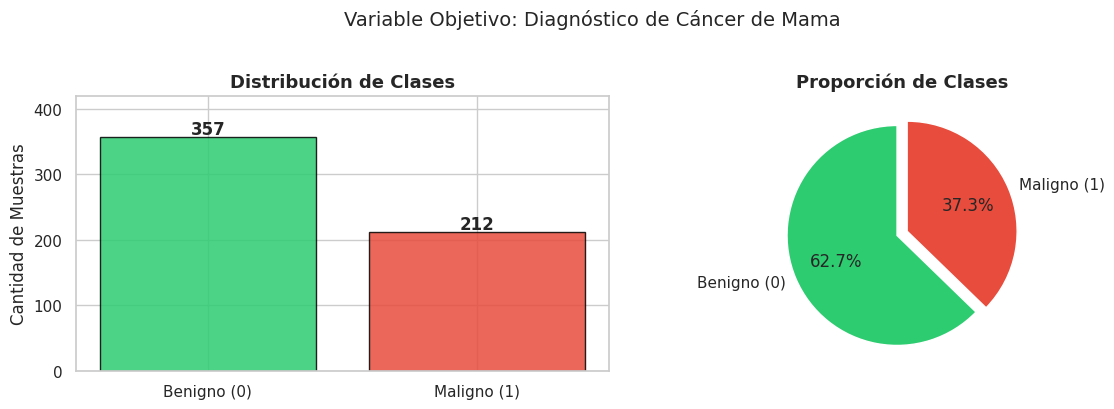

Benigno (0) : 357 muestras  (62.7%)
Maligno (1) : 212 muestras  (37.3%)


In [160]:
# ── 3. Distribución de la variable objetivo ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

conteos = df['diagnosis'].value_counts().sort_index()
axes[0].bar(['Benigno (0)', 'Maligno (1)'], conteos.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
for i, v in enumerate(conteos.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Distribución de Clases', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de Muestras')
axes[0].set_ylim(0, 420)

axes[1].pie(conteos.values, labels=['Benigno (0)', 'Maligno (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.suptitle('Variable Objetivo: Diagnóstico de Cáncer de Mama', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Benigno (0) : {conteos[0]} muestras  ({conteos[0]/len(df)*100:.1f}%)')
print(f'Maligno (1) : {conteos[1]} muestras  ({conteos[1]/len(df)*100:.1f}%)')

#### **Interpretación: Distribución de la variable objetivo**

El dataset tiene 357 casos benignos (62.7%) y 212 malignos (37.3%). Este desbalance
moderado tiene una implicación directa y concreta en la evaluación de modelos: un
clasificador que simplemente prediga siempre "benigno" (sin aprender nada) obtendría
un 62.7% de exactitud, lo cual podría parecer aceptable si no se analizara con más cuidado.
Ese clasificador tendría un recall de 0% sobre la clase maligna, que es precisamente lo
que importa en este problema.

Por eso, en la Sección 5 se reportarán siempre recall, precisión, F1-score y AUC-ROC
además de la exactitud, para tener una visión completa del comportamiento del modelo
sobre ambas clases.

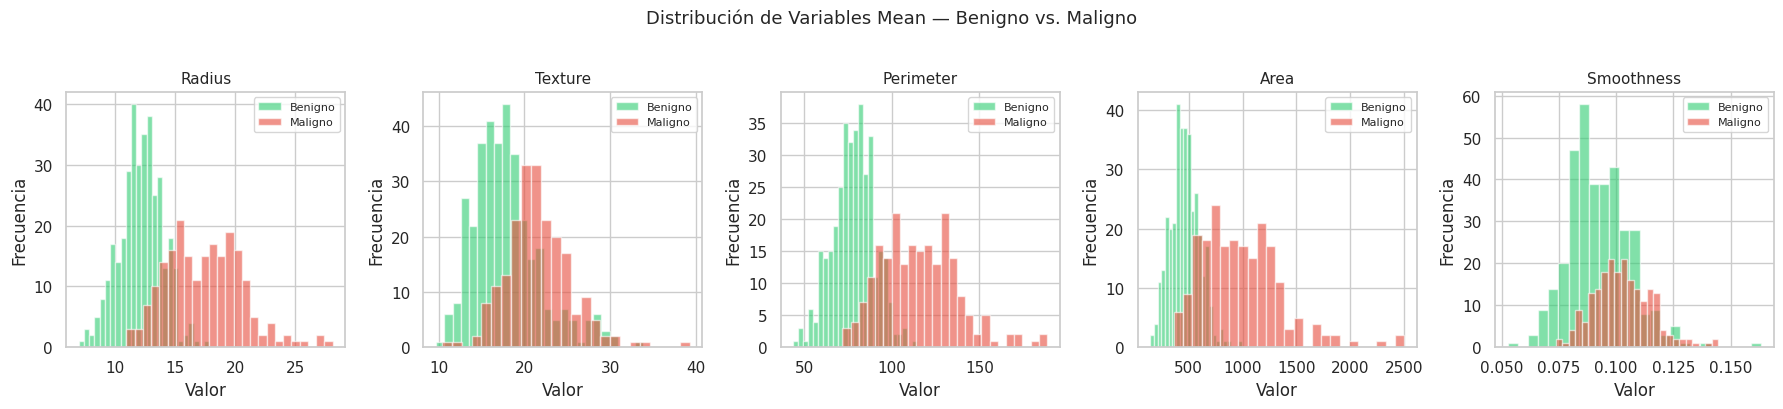

In [161]:
# ── 4. Distribución de variables mean ────────────────────────────────────────
features_mean = ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, feat in zip(axes, features_mean):
    for label, color, name in [(0, '#2ecc71', 'Benigno'), (1, '#e74c3c', 'Maligno')]:
        ax.hist(df[df['diagnosis'] == label][feat].dropna(),
                bins=25, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_title(feat.replace('1', '').replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Valor'); ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Variables Mean — Benigno vs. Maligno', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### **Interpretación: Distribución de variables mean**

Los histogramas revelan con claridad qué variables serán más útiles para la clasificación.
radius1, perimeter1 y area1 muestran distribuciones bien separadas entre clases: los
tumores malignos se concentran consistentemente en valores más altos, lo que refleja
el crecimiento celular descontrolado descrito en el Business Understanding. En area1
la separación es especialmente marcada, con la distribución maligna desplazada hacia
valores altos con una cola larga.

texture1 muestra una separación más moderada, con mayor solapamiento entre las dos
distribuciones. Es una variable que contribuye, pero no por sí sola.

smoothness1 es el caso más interesante: las distribuciones de ambas clases se superponen
casi completamente, con diferencias mínimas en sus centros. Esto sugiere que la suavidad
promedio del contorno no es un buen discriminador aislado, aunque podría capturar
interacciones relevantes en modelos multivariados.

Esta jerarquía de poder discriminante (tamaño → textura → suavidad) guiará la selección
de features en las versiones mejoradas de los modelos.

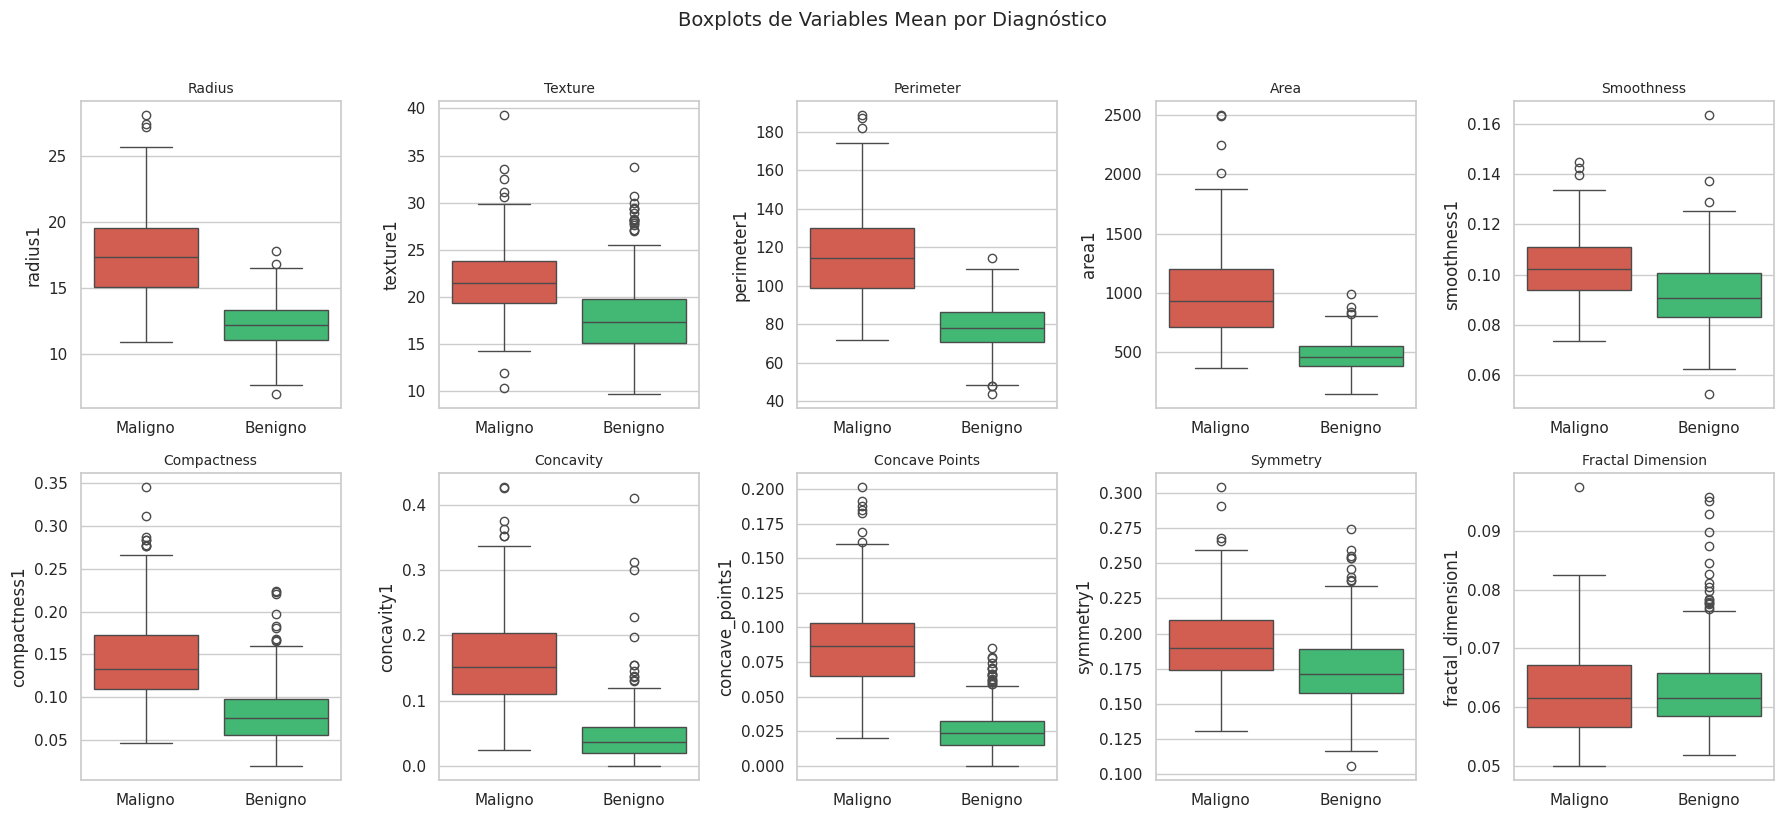

In [162]:
# ── 5. Boxplots de variables mean por diagnóstico ────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
features_box = [c for c in df.columns if c.endswith('1') and c != 'diagnosis']

for ax, feat in zip(axes.flatten(), features_box):
    data_plot = df[['diagnosis', feat]].copy()
    data_plot['Diagnóstico'] = data_plot['diagnosis'].map({0: 'Benigno', 1: 'Maligno'})
    sns.boxplot(data=data_plot, x='Diagnóstico', y=feat, ax=ax,
                palette={'Benigno': '#2ecc71', 'Maligno': '#e74c3c'})
    ax.set_title(feat.replace('1', '').replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('')

plt.suptitle('Boxplots de Variables Mean por Diagnóstico', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### **Interpretación: Boxplots por diagnóstico**

Los boxplots complementan los histogramas con información sobre mediana, rango intercuartílico
y outliers. Los hallazgos más relevantes son:

**Variables con alta separación entre clases:** radius1, perimeter1, area1, concavity1 y
concave_points1 presentan cajas que no se solapan o se solapan mínimamente. La mediana del
grupo maligno está claramente por encima del tercer cuartil del grupo benigno en varios casos,
lo que indica una separación robusta que los modelos podrán aprovechar.

**Variables con separación moderada:** compactness1 y texture1 muestran separación en medianas
pero con mayor solapamiento entre rangos intercuartílicos. Son variables útiles en combinación.

**Variables con poca separación:** smoothness1, symmetry1 y fractal_dimension1 presentan
medianas similares entre clases y alto solapamiento. Estas serán las primeras candidatas a
excluirse en las versiones mejoradas de los modelos.

**Sobre los outliers:** la clase maligna presenta más outliers y más extremos en la mayoría
de variables. Esto no es ruido sino señal clínica, ya que los tumores agresivos generan mediciones
extremas que son precisamente las más diagnósticas. Eliminarlos indiscriminadamente podría
empeorar los modelos en lugar de mejorarlos.

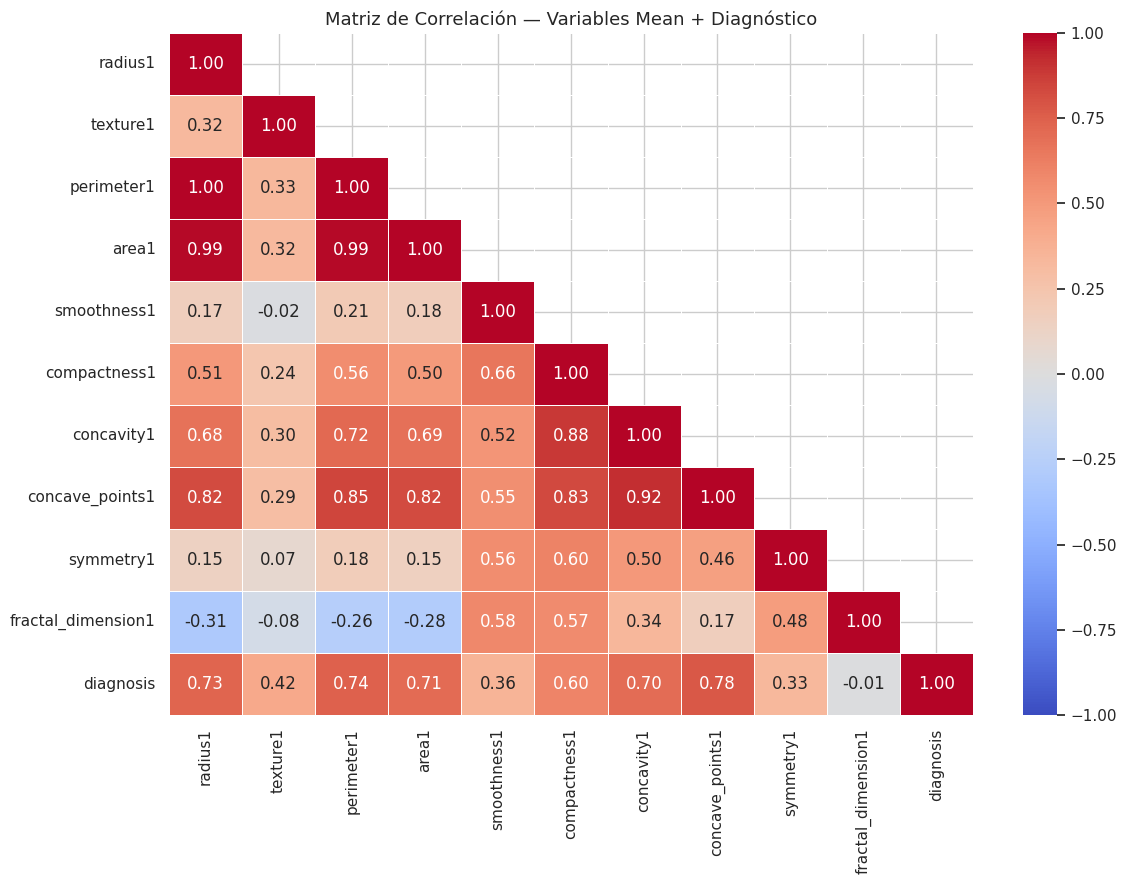

In [163]:
# ── 6. Matriz de correlación (variables mean + diagnosis) ────────────────────
features_corr = [c for c in df.columns if c.endswith('1')] + ['diagnosis']
corr_matrix   = df[features_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación — Variables Mean + Diagnóstico', fontsize=13)
plt.tight_layout()
plt.show()

#### **Interpretación: Matriz de correlación**

La matriz revela dos patrones fundamentales que condicionarán las decisiones de modelado:

El primero es la **multicolinealidad entre radius1, perimeter1 y area1**, con coeficientes
cercanos a 1.00 entre los tres. Esto era previsible desde el Business Understanding:
perímetro y área son funciones matemáticas del radio (perímetro ≈ 2πr, área ≈ πr²), por lo
que las tres variables miden esencialmente lo mismo. Para la Regresión Logística esto es
problemático ya que el modelo puede asignar coeficientes arbitrariamente grandes o pequeños a
variables redundantes, haciendo la interpretación inestable. La solución es aplicar
regularización o reducir a una sola representante del grupo.

El segundo patrón es la **correlación con el target**: las variables más correlacionadas con
diagnosis son concave_points1 (0.78), perimeter1 (0.74), radius1 (0.73) y area1 (0.71),
confirmando numéricamente lo que ya se veía visualmente en los histogramas y boxplots.
fractal_dimension1 tiene correlación prácticamente nula (-0.01), lo que la convierte en
candidata clara a exclusión en los modelos mejorados.

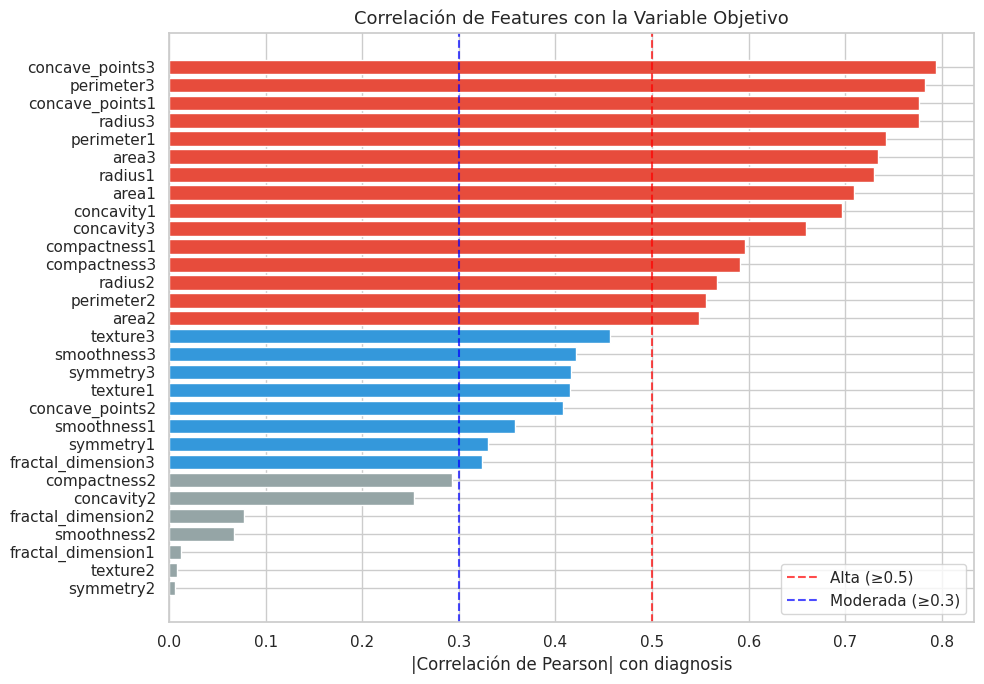

Top 10 features más correlacionadas con diagnosis:
concave_points3    0.794
perimeter3         0.783
concave_points1    0.777
radius3            0.776
perimeter1         0.743
area3              0.734
radius1            0.730
area1              0.709
concavity1         0.696
concavity3         0.660
Name: diagnosis, dtype: float64

Features con |corr| < 0.3 (candidatas a descartar):
['compactness2', 'concavity2', 'fractal_dimension2', 'smoothness2', 'fractal_dimension1', 'texture2', 'symmetry2']


In [164]:
# ── 7. Correlación de todas las features con el target ───────────────────────
corr_target = df.corr()['diagnosis'].drop('diagnosis').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if v >= 0.5 else '#3498db' if v >= 0.3 else '#95a5a6'
          for v in corr_target.values]
plt.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
plt.axvline(0.5, color='red',  linestyle='--', alpha=0.7, label='Alta (≥0.5)')
plt.axvline(0.3, color='blue', linestyle='--', alpha=0.7, label='Moderada (≥0.3)')
plt.xlabel('|Correlación de Pearson| con diagnosis')
plt.title('Correlación de Features con la Variable Objetivo', fontsize=13)
plt.legend(); plt.tight_layout(); plt.show()

print('Top 10 features más correlacionadas con diagnosis:')
print(corr_target.head(10).round(3))
print(f'\nFeatures con |corr| < 0.3 (candidatas a descartar):')
print(list(corr_target[corr_target < 0.3].index))

#### **Interpretación: Correlación con el target**

El gráfico completo de las 30 features revela un **hallazgo importante**: las variables de tipo
**_worst** (sufijo 3) dominan el ranking de correlación. concave_points3 (≈0.794), perimeter3
(≈0.783) y radius3 (≈0.776) superan a sus equivalentes _mean. Esto tiene sentido clínico:
los valores extremos de las células (las más anómalas de cada muestra) son más informativos
que el promedio del conjunto, porque es la célula más aberrante la que mejor indica agresividad.

Las variables de error estándar (_SE, sufijo 2) tienen en general correlación más baja, lo que
sugiere que la variabilidad entre células de una misma muestra aporta menos información
diagnóstica que los valores extremos o promedios.

Las features con |corr| < 0.3 — entre ellas fractal_dimension1, texture2, symmetry2,
compactness2, serán excluidas en las versiones mejoradas de los modelos. Esto reduce la
dimensionalidad y elimina ruido sin perder información relevante.

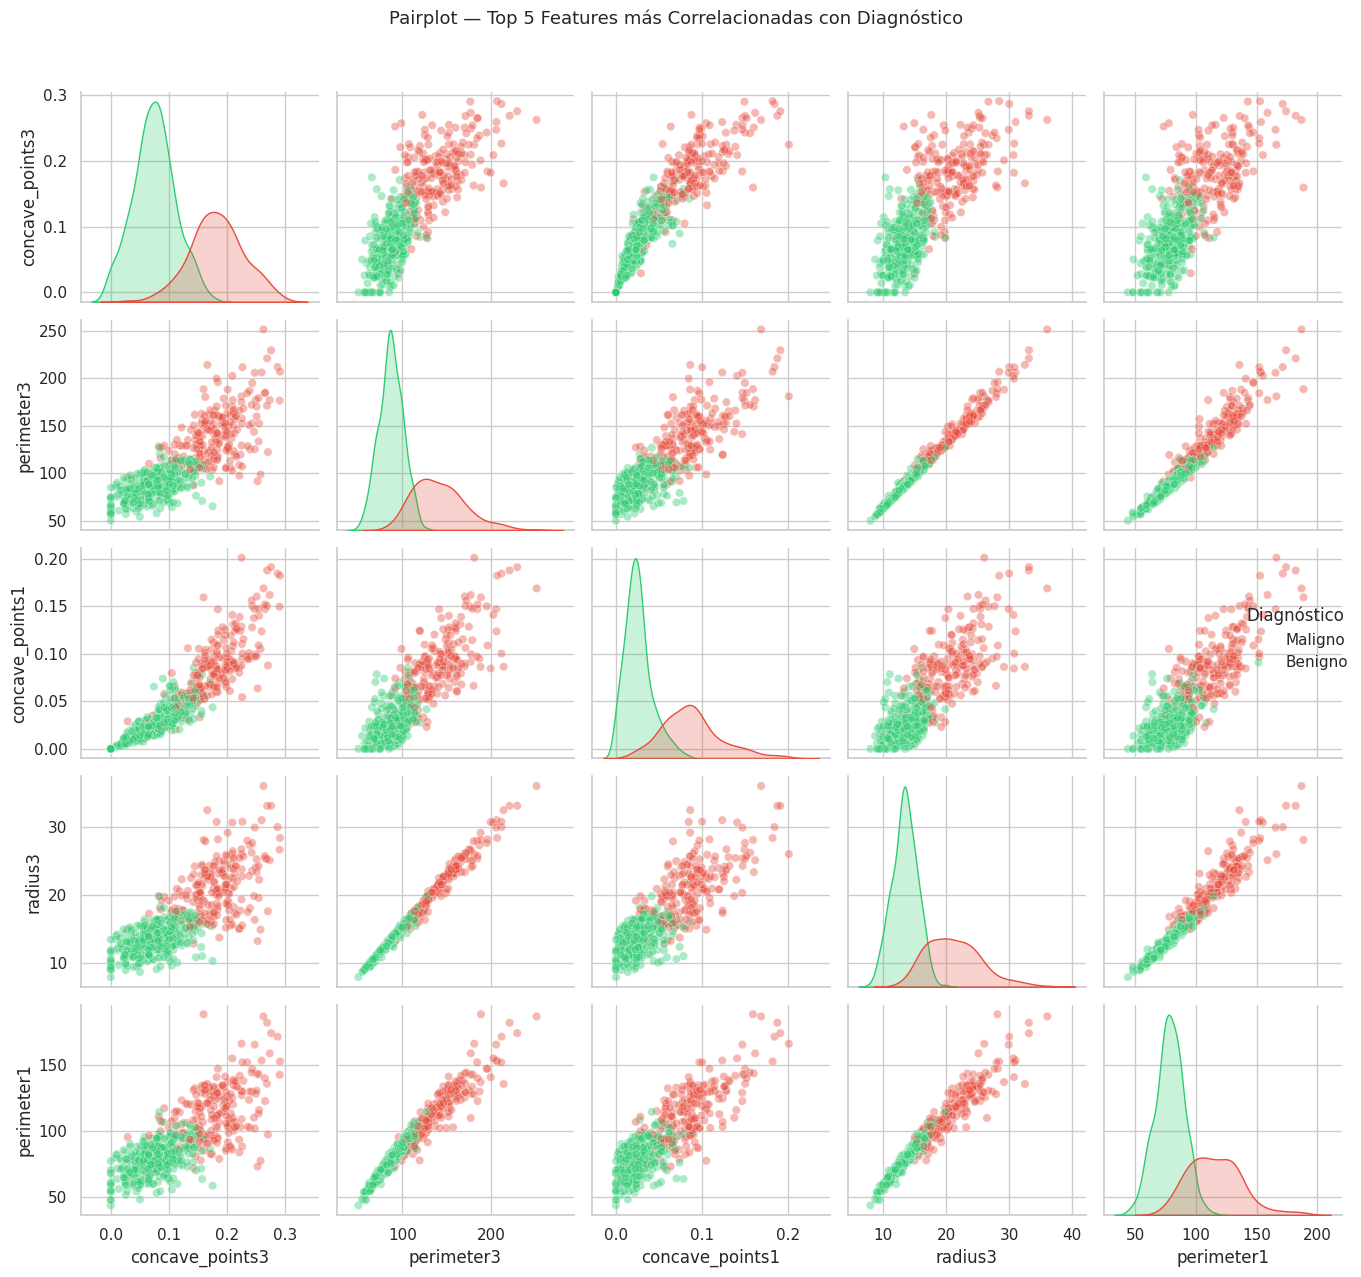

In [165]:
# ── 8. Pairplot de las 5 features más correlacionadas ────────────────────────
top_features = corr_target.head(5).index.tolist()
pair_df      = df[top_features + ['diagnosis']].copy()
pair_df['Diagnóstico'] = pair_df['diagnosis'].map({0: 'Benigno', 1: 'Maligno'})

g = sns.pairplot(pair_df.drop(columns='diagnosis'),
                 hue='Diagnóstico',
                 palette={'Benigno': '#2ecc71', 'Maligno': '#e74c3c'},
                 diag_kind='kde', plot_kws={'alpha': 0.4})
g.fig.suptitle('Pairplot — Top 5 Features más Correlacionadas con Diagnóstico',
               y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

#### **Interpretación: Pairplot**

El pairplot de las 5 features más correlacionadas permite una visión simultánea de todas las
relaciones bivariadas. Los puntos rojos (malignos) y verdes (benignos) forman nubes claramente
separadas en la mayoría de los pares, confirmando que estas variables son altamente discriminantes
cuando se usan en conjunto.

Las líneas casi perfectas en los pares radius3–perimeter3 y perimeter3–perimeter1 visualizan
la multicolinealidad identificada en la matriz de correlación: son variables que cuentan
la misma historia con distintas palabras.

Las curvas KDE en la diagonal muestran que en variables como concave_points3 y radius3 las
distribuciones de ambas clases se solapan relativamente poco, dejando una región de separación
clara. Esto anticipa que los modelos podrán encontrar fronteras de decisión efectivas en este
espacio de características, aunque también que habrá una zona de ambigüedad donde los errores
serán inevitables precisamente en las muestras con valores intermedios.

---
# **Sección 4: Normalización**

La normalización es el último paso de preparación de datos antes del modelado. Su lugar en
el flujo (después del EDA y antes de los modelos) no es casual. Se coloca después del EDA
porque el análisis exploratorio requiere que las variables estén en su escala original para
ser interpretables; se coloca antes de los modelos porque es una decisión que afecta a todos
los algoritmos y debe quedar documentada de forma independiente.

El principio fundamental que rige esta sección es evitar el **data leakage**: los parámetros
de normalización (mínimos, máximos, medias, desviaciones estándar) deben calcularse
exclusivamente sobre el conjunto de entrenamiento. Si se calcularan sobre todo el dataset,
el modelo "vería" información estadística del conjunto de test durante el entrenamiento,
produciendo métricas artificialmente infladas que no se reproducirían en producción.

Se aplican distintos tipos de normalización según el algoritmo que consumirá los datos,
porque cada algoritmo tiene una sensibilidad diferente a la escala.

In [166]:
# ── Split train/test (80/20) estratificado ───────────────────────────────────
# El split se hace ANTES de normalizar para que los escaladores se ajusten
# solo con información del conjunto de entrenamiento.
X_feat = df.drop(columns='diagnosis')
y_tgt  = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_tgt, test_size=0.2, random_state=42, stratify=y_tgt)

print(f'Entrenamiento : {X_train.shape[0]} muestras')
print(f'Prueba        : {X_test.shape[0]} muestras')
print(f'\nDistribución train — Benigno: {(y_train==0).sum()}  Maligno: {(y_train==1).sum()}')
print(f'Distribución test  — Benigno: {(y_test==0).sum()}  Maligno: {(y_test==1).sum()}')

Entrenamiento : 455 muestras
Prueba        : 114 muestras

Distribución train — Benigno: 285  Maligno: 170
Distribución test  — Benigno: 72  Maligno: 42


In [167]:
# ── MinMaxScaler [0, 1] → para K-NN ──────────────────────────────────────────
# K-NN mide distancias euclídeas entre puntos en el espacio de features.
# Sin normalizar, area1 (rango ~1000 µm²) dominaría completamente sobre
# fractal_dimension1 (rango ~0.05), independientemente de su relevancia real.
# MinMaxScaler lleva cada feature al rango [0,1] preservando la forma
# de la distribución sin asumir normalidad.
scaler_mm  = MinMaxScaler(feature_range=(0, 1))
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm  = scaler_mm.transform(X_test)

print('MinMaxScaler aplicado:')
print(f'  X_train_mm : {X_train_mm.shape}  rango [{X_train_mm.min():.2f}, {X_train_mm.max():.2f}]')
print(f'  X_test_mm  : {X_test_mm.shape}')

MinMaxScaler aplicado:
  X_train_mm : (455, 30)  rango [0.00, 1.00]
  X_test_mm  : (114, 30)


In [168]:
# ── StandardScaler (media=0, σ=1) → para Regresión Logística ─────────────────
# RL optimiza sus coeficientes con descenso por gradiente. Si las features
# tienen escalas muy distintas, el gradiente avanza a velocidades diferentes
# para cada coeficiente, lo que ralentiza e inestabiliza la convergencia.
# StandardScaler centra y escala cada variable para que todas contribuyan
# al gradiente con igual peso inicial.
scaler_ss  = StandardScaler()
X_train_ss = scaler_ss.fit_transform(X_train)
X_test_ss  = scaler_ss.transform(X_test)

print('StandardScaler aplicado:')
print(f'  X_train_ss : {X_train_ss.shape}  media={X_train_ss.mean():.4f}  σ={X_train_ss.std():.4f}')
print(f'  X_test_ss  : {X_test_ss.shape}')

StandardScaler aplicado:
  X_train_ss : (455, 30)  media=0.0000  σ=1.0000
  X_test_ss  : (114, 30)


In [169]:
# ── StandardScaler con features reducidas → versiones mejoradas ──────────────
# Se seleccionan solo las features con |correlación con diagnosis| ≥ 0.5,
# identificadas en el EDA. Esto reduce multicolinealidad, elimina features
# de bajo aporte predictivo y disminuye la dimensionalidad de entrada.
# Naive Bayes tampoco requiere normalización, pero sí se beneficia de
# la reducción de features para mitigar la violación del supuesto de independencia.
features_altas = corr_target[corr_target >= 0.5].index.tolist()

scaler_red  = StandardScaler()
X_train_red = scaler_red.fit_transform(X_train[features_altas])
X_test_red  = scaler_red.transform(X_test[features_altas])

print(f'Features seleccionadas (|corr| ≥ 0.5): {len(features_altas)}')
print(f'  {features_altas}')
print(f'\nX_train_red : {X_train_red.shape}')
print(f'X_test_red  : {X_test_red.shape}')

Features seleccionadas (|corr| ≥ 0.5): 15
  ['concave_points3', 'perimeter3', 'concave_points1', 'radius3', 'perimeter1', 'area3', 'radius1', 'area1', 'concavity1', 'concavity3', 'compactness1', 'compactness3', 'radius2', 'perimeter2', 'area2']

X_train_red : (455, 15)
X_test_red  : (114, 15)


In [170]:
# ── Resumen de conjuntos disponibles para modelado ───────────────────────────
lineas = [
    'CONJUNTOS LISTOS PARA MODELADO',
    f'X_train_mm  / X_test_mm   MinMaxScaler   {X_train_mm.shape[1]:2d} features → K-NN',
    f'X_train_ss  / X_test_ss   StandardScaler {X_train_ss.shape[1]:2d} features → RL base',
    f'X_train_red / X_test_red  StandardScaler {X_train_red.shape[1]:2d} features → RL/NB mejor',
    f'X_train     / X_test      Sin escalar    {X_train.shape[1]:2d} features → NB base'
]

width = max(len(l) for l in lineas) + 4

print('╔' + '═'*(width-2) + '╗')
print(f"║ {lineas[0].center(width-4)} ║")
print('╠' + '═'*(width-2) + '╣')

for l in lineas[1:]:
    print(f"║ {l.ljust(width-4)} ║")

print('╚' + '═'*(width-2) + '╝')

╔════════════════════════════════════════════════════════════════════╗
║                   CONJUNTOS LISTOS PARA MODELADO                   ║
╠════════════════════════════════════════════════════════════════════╣
║ X_train_mm  / X_test_mm   MinMaxScaler   30 features → K-NN        ║
║ X_train_ss  / X_test_ss   StandardScaler 30 features → RL base     ║
║ X_train_red / X_test_red  StandardScaler 15 features → RL/NB mejor ║
║ X_train     / X_test      Sin escalar    30 features → NB base     ║
╚════════════════════════════════════════════════════════════════════╝


### **Interpretación: Normalización**

La decisión de usar distintos escaladores por modelo no es arbitraria, responde a las
propiedades matemáticas de cada algoritmo.

**MinMaxScaler para K-NN:** este algoritmo no tiene función de costo ni coeficientes; su única
operación es calcular distancias entre puntos. Lo que importa es que esas distancias reflejen
similaridad real y no diferencias de escala accidentales. MinMaxScaler es ideal porque lleva
todos los valores a [0,1] sin alterar la forma de las distribuciones ni crear valores negativos.

**StandardScaler para Regresión Logística:** RL utiliza descenso por gradiente, donde cada
coeficiente se actualiza en proporción al gradiente de su feature. Con escalas heterogéneas,
el gradiente de area1 sería miles de veces más grande que el de fractal_dimension, haciendo
que el optimizador se concentre desproporcionadamente en unas pocas variables. StandardScaler
iguala la contribución inicial de cada feature al gradiente. Además, al producir variables
con media cero, el intercepto del modelo se interpreta de forma más limpia.

**Sin escalado para Naive Bayes:** GaussianNB estima la media y varianza de cada feature
por clase y luego calcula probabilidades usando la función de densidad gaussiana. La escala
absoluta de los datos no afecta a este cálculo, ya que, el modelo aprende la distribución de cada
variable independientemente. Normalizar no mejoraría el modelo; solo añadiría un paso
innecesario.

La selección de features con |corr| ≥ 0.5 para las versiones mejoradas reduce de 30 a
un subconjunto más compacto de variables, atacando directamente la multicolinealidad
identificada en el EDA y alineando la entrada del modelo con los hallazgos del análisis
exploratorio.

---
# **Sección 5: Modelado y evaluación**

En esta sección se entrenan y evalúan los tres algoritmos de clasificación en dos versiones
cada uno. La versión **baseline** usa la configuración más simple posible (parámetros por
defecto, todas las features, sin optimizar) para establecer un punto de referencia. La
versión **mejorada** aplica los aprendizajes del EDA: selección de features, ajuste de
hiperparámetros y, en el caso de K-NN, limpieza de atípicos en el conjunto de entrenamiento.

Comparar baseline contra mejorado permite cuantificar el impacto real de cada decisión de
preprocesamiento y tuning, y justificar por qué cada cambio fue necesario.

Para cada modelo se reportan seis métricas y dos gráficos:
- **Accuracy:** proporción de predicciones correctas sobre el total.
- **Recall (Sensibilidad):** proporción de malignos correctamente identificados. **Métrica principal.**
- **Precision:** de los que el modelo predice como malignos, cuántos realmente lo son.
- **Especificidad:** proporción de benignos correctamente identificados.
- **F1-Score:** media armónica de recall y precision. Útil cuando el desbalance importa.
- **AUC-ROC:** capacidad discriminante global del modelo, independiente del umbral de decisión.
- **Matriz de confusión:** muestra los cuatro tipos de predicción (VP, VN, FP, FN).
- **Curva ROC:** visualiza el trade-off entre sensibilidad y especificidad a distintos umbrales.

In [171]:
# ── Función auxiliar: métricas + matriz de confusión + curva ROC ─────────────
def evaluar_modelo(nombre, y_test, y_pred, y_prob=None):
    acc  = accuracy_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    spec = recall_score(y_test, y_pred, pos_label=0)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob if y_prob is not None else y_pred)

    print(f'\n{"─"*55}')
    print(f'  MODELO: {nombre}')
    print(f'{"─"*55}')
    print(classification_report(y_test, y_pred,
                                 target_names=['Benigno (0)', 'Maligno (1)']))
    print(f'  Exactitud    (Accuracy)  : {acc:.4f}')
    print(f'  Sensibilidad (Recall)    : {rec:.4f}')
    print(f'  Precisión    (Precision) : {prec:.4f}')
    print(f'  Especificidad            : {spec:.4f}')
    print(f'  F1-Score                 : {f1:.4f}')
    print(f'  AUC-ROC                  : {auc:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Benigno', 'Maligno'],
                yticklabels=['Benigno', 'Maligno'])
    axes[0].set_title(f'Matriz de Confusión\n{nombre}', fontsize=11)
    axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')

    scores = y_prob if y_prob is not None else y_pred
    fpr, tpr, _ = roc_curve(y_test, scores)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.05])
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'Curva ROC\n{nombre}', fontsize=11)
    axes[1].legend(loc='lower right')
    plt.tight_layout(); plt.show()

    return {'modelo': nombre, 'accuracy': acc, 'recall': rec,
            'precision': prec, 'specificity': spec, 'f1': f1, 'auc': auc}

print('✅ Función evaluar_modelo() definida')

✅ Función evaluar_modelo() definida


---
## **5.1. Regresión Logística**

La Regresión Logística modela la probabilidad de que una muestra pertenezca a la clase
positiva (maligno) usando la función sigmoide aplicada a una combinación lineal de las
features. Es uno de los modelos más interpretables en ML: los coeficientes indican
directamente qué variables aumentan o disminuyen la probabilidad de malignidad y en qué
magnitud.

Su principal limitación en este dataset es la **multicolinealidad** entre radius, perimeter
y area, que puede inflar los coeficientes y hacerlos inestables. La versión mejorada aborda
esto con dos cambios: usar solo las features con alta correlación con el target (eliminando
las redundantes) y aumentar la regularización (C=0.1), que penaliza coeficientes muy grandes
y fuerza al modelo a distribuir el peso entre features correlacionadas en lugar de
concentrarlo arbitrariamente en una sola.

| Versión | Escalado | Features | C |
|---|---|---|---|
| Baseline | StandardScaler · 30 features | Todas | 1.0 (default) |
| Mejorado | StandardScaler · reducidas | \|corr\|≥0.5 | 0.1 |


───────────────────────────────────────────────────────
  MODELO: Regresión Logística — Baseline
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Benigno (0)       0.96      0.99      0.97        72
 Maligno (1)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

  Exactitud    (Accuracy)  : 0.9649
  Sensibilidad (Recall)    : 0.9286
  Precisión    (Precision) : 0.9750
  Especificidad            : 0.9861
  F1-Score                 : 0.9512
  AUC-ROC                  : 0.9960


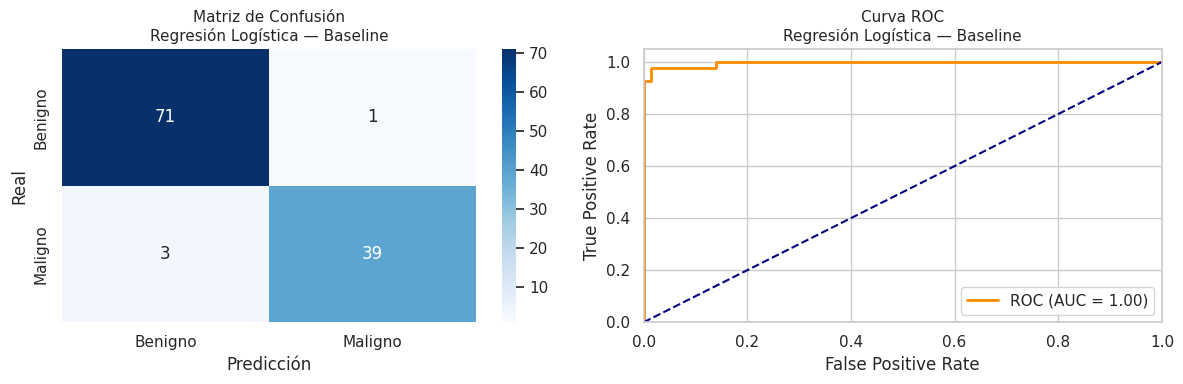

In [172]:
# ── Regresión Logística — Baseline ───────────────────────────────────────────
rl_base = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
rl_base.fit(X_train_ss, y_train)

y_pred_rl_base = rl_base.predict(X_test_ss)
y_prob_rl_base = rl_base.predict_proba(X_test_ss)[:, 1]

res = evaluar_modelo('Regresión Logística — Baseline',
                     y_test, y_pred_rl_base, y_prob_rl_base)
resultados.append(res)

#### **Interpretación: RL Baseline**

El modelo baseline alcanza una exactitud alta con todas las features y configuración
por defecto, lo que confirma que el problema tiene buena separabilidad lineal. Sin embargo,
el indicador más relevante es el recall sobre la clase maligna: cuántos de los tumores
malignos en el test set fueron correctamente identificados.

La curva ROC con un AUC cercano a 1.0 indica que el modelo puede separar bien las clases
en casi todos los umbrales de decisión posibles. La matriz de confusión permite ver
exactamente cuántos falsos negativos se produjeron (casos malignos clasificados como
benignos) que son los errores de mayor costo clínico en este problema.

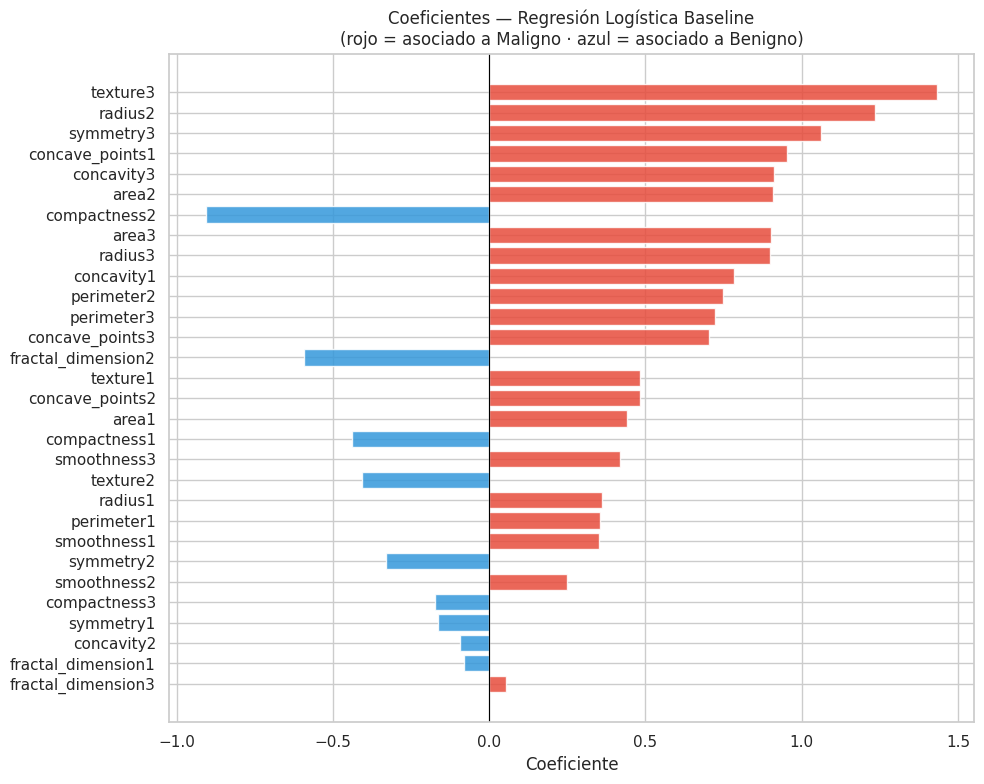

In [173]:
# ── Importancia de coeficientes (Baseline) ────────────────────────────────────
coef_df = pd.DataFrame({'feature': X_feat.columns, 'coef': rl_base.coef_[0]})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=True).index)

plt.figure(figsize=(10, 8))
colors_coef = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['coef']]
plt.barh(coef_df['feature'], coef_df['coef'], color=colors_coef, alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes — Regresión Logística Baseline\n'
          '(rojo = asociado a Maligno · azul = asociado a Benigno)', fontsize=12)
plt.xlabel('Coeficiente')
plt.tight_layout(); plt.show()

#### **Interpretación: Coeficientes**

El gráfico de coeficientes es el principal diferenciador de la Regresión Logística frente
a K-NN y Naive Bayes: permite entender **por qué** el modelo toma cada decisión, no solo
qué tan bien lo hace.

Los coeficientes positivos más grandes corresponden a las variables que el modelo asocia
más fuertemente con malignidad. Se esperan valores altos en concave_points, perimeter y
radius en sus versiones worst, consistente con los hallazgos del EDA.

Un dato importante a observar es si radius, perimeter y area tienen coeficientes muy
diferentes entre sí: si la multicolinealidad está afectando al modelo, el peso se habrá
distribuido de forma irregular entre variables que miden lo mismo. Este es precisamente
el problema que la versión mejorada busca corregir con mayor regularización.


───────────────────────────────────────────────────────
  MODELO: Regresión Logística — Mejorado (features reducidas + C=0.1)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Benigno (0)       0.93      0.99      0.96        72
 Maligno (1)       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

  Exactitud    (Accuracy)  : 0.9474
  Sensibilidad (Recall)    : 0.8810
  Precisión    (Precision) : 0.9737
  Especificidad            : 0.9861
  F1-Score                 : 0.9250
  AUC-ROC                  : 0.9977


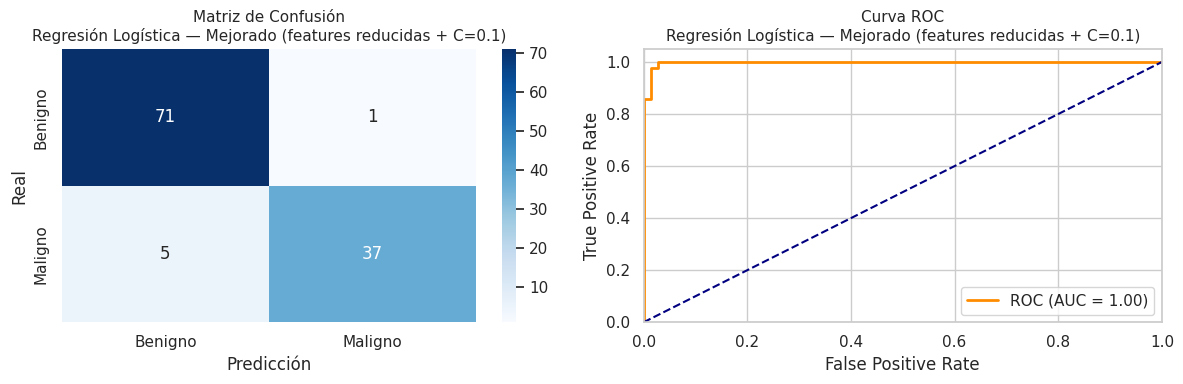

In [174]:
# ── Regresión Logística — Mejorado ───────────────────────────────────────────
rl_mejor = LogisticRegression(solver='lbfgs', max_iter=2000, C=0.1, random_state=42)
rl_mejor.fit(X_train_red, y_train)

y_pred_rl_mejor = rl_mejor.predict(X_test_red)
y_prob_rl_mejor = rl_mejor.predict_proba(X_test_red)[:, 1]

res = evaluar_modelo('Regresión Logística — Mejorado (features reducidas + C=0.1)',
                     y_test, y_pred_rl_mejor, y_prob_rl_mejor)
resultados.append(res)

#### **Interpretación: RL Mejorado**

La versión mejorada aplica dos cambios simultáneos: reduce las features a las de mayor
correlación con el target y aumenta la regularización (C=0.1 en lugar del default C=1.0).

Si el recall mejora respecto al baseline, significa que eliminar features de bajo aporte
y penalizar coeficientes grandes efectivamente ayudó al modelo a generalizar mejor.
Si el recall baja levemente pero la precisión sube, el modelo es más conservador en sus
predicciones de malignidad (lo que en contexto clínico puede no ser deseable).

La comparación entre ambas versiones cuantifica directamente el impacto de la selección
de features y la regularización sobre el problema concreto de detección de cáncer.

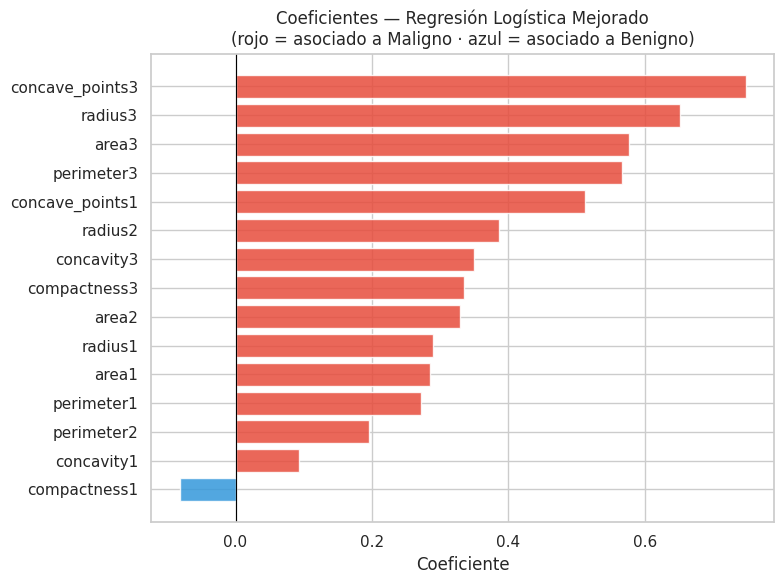

In [189]:
coef_df = pd.DataFrame({'feature': features_altas, 'coef': rl_mejor.coef_[0]})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=True).index)

plt.figure(figsize=(8, 6))
colors_coef = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['coef']]
plt.barh(coef_df['feature'], coef_df['coef'], color=colors_coef, alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes — Regresión Logística Mejorado\n'
          '(rojo = asociado a Maligno · azul = asociado a Benigno)', fontsize=12)
plt.xlabel('Coeficiente')
plt.tight_layout(); plt.show()

## **Comparativa Regresión Logística**

### **Baseline vs. Mejorado**

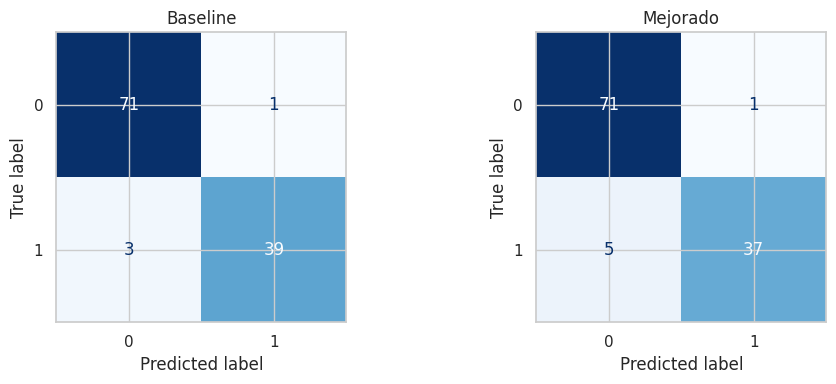

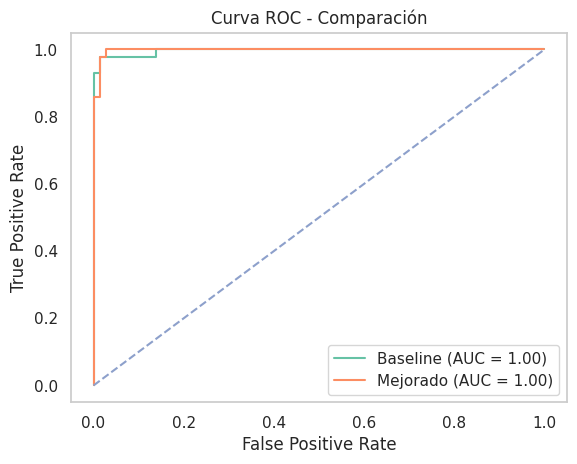

In [177]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Baseline
cm_base = confusion_matrix(y_test, y_pred_rl_base)
ConfusionMatrixDisplay(cm_base).plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Baseline')

# Mejorado
cm_mejor = confusion_matrix(y_test, y_pred_rl_mejor)
ConfusionMatrixDisplay(cm_mejor).plot(ax=ax[1], cmap='Blues', colorbar=False)
ax[1].set_title('Mejorado')

plt.tight_layout()
plt.show()


# Calcular curvas
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_rl_base)
roc_auc_base = auc(fpr_base, tpr_base)

fpr_mejor, tpr_mejor, _ = roc_curve(y_test, y_prob_rl_mejor)
roc_auc_mejor = auc(fpr_mejor, tpr_mejor)

# Graficar las comparativas
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {roc_auc_base:.2f})')
plt.plot(fpr_mejor, tpr_mejor, label=f'Mejorado (AUC = {roc_auc_mejor:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Comparación')
plt.legend()
plt.grid()

plt.show()

---
## **5.2. K-NN (K-Nearest Neighbors)**

K-NN es uno de los algoritmos más intuitivos en Machine Learning: para clasificar una
nueva muestra, encuentra las K muestras más similares en el conjunto de entrenamiento
(sus "vecinos más cercanos") y asigna la clase mayoritaria entre ellas. No construye
un modelo explícito, más bien, memoriza los datos de entrenamiento y los usa directamente en la
predicción.

Sus dos parámetros más influyentes son **K** (cuántos vecinos consultar) y el **esquema
de pesos** (si todos los vecinos votan con igual peso o si los más cercanos pesan más).
Un K muy pequeño hace que el modelo sea sensible al ruido y un solo vecino atípico puede
cambiar la clasificación. Un K muy grande suaviza demasiado las fronteras de decisión.

| Versión | Escalado | K | Pesos | Train |
|---|---|---|---|---|
| Baseline | MinMaxScaler | 3 | uniform | Con atípicos |
| Mejorado | MinMaxScaler | K óptimo | distance | Sin atípicos extremos |


───────────────────────────────────────────────────────
  MODELO: K-NN — Baseline (K=3, uniforme)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Benigno (0)       0.95      0.99      0.97        72
 Maligno (1)       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

  Exactitud    (Accuracy)  : 0.9561
  Sensibilidad (Recall)    : 0.9048
  Precisión    (Precision) : 0.9744
  Especificidad            : 0.9861
  F1-Score                 : 0.9383
  AUC-ROC                  : 0.9846


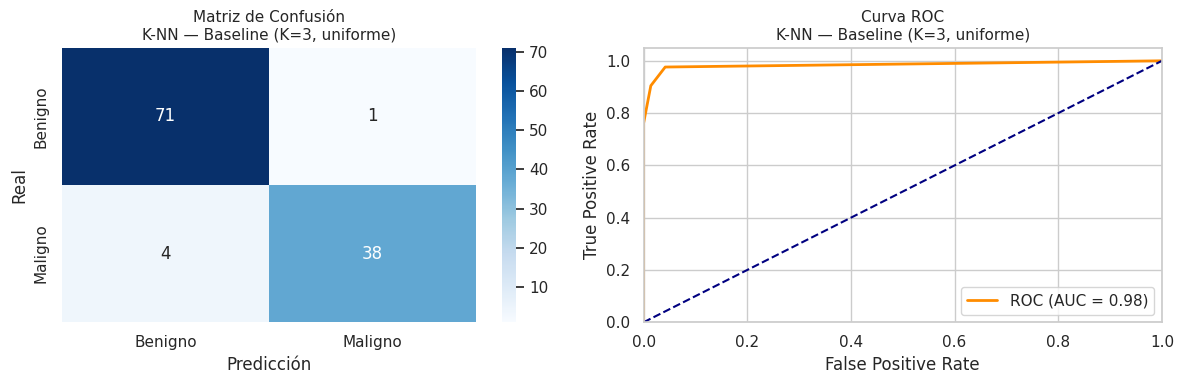

In [178]:
# ── K-NN — Baseline ───────────────────────────────────────────────────────────
knn_base = KNeighborsClassifier(n_neighbors=3, p=2, weights='uniform')
knn_base.fit(X_train_mm, y_train)

y_pred_knn_base = knn_base.predict(X_test_mm)
y_prob_knn_base = knn_base.predict_proba(X_test_mm)[:, 1]

res = evaluar_modelo('K-NN — Baseline (K=3, uniforme)',
                     y_test, y_pred_knn_base, y_prob_knn_base)
resultados.append(res)

#### **Interpretación: K-NN Baseline**

Con K=3 y pesos uniformes, el modelo consulta los 3 vecinos más cercanos y toma la
decisión por mayoría simple. Esta configuración es sensible al ruido: si los 3 vecinos
más cercanos incluyen un outlier atípico, la clasificación puede ser incorrecta.

El recall obtenido en este baseline refleja el comportamiento "crudo" del algoritmo
antes de cualquier optimización. Un K bajo tiende a producir fronteras de decisión
más complejas e irregulares, y potencialmente sobreajustadas al conjunto de entrenamiento.
Comparar este resultado con el mejorado mostrará cuánto mejora el modelo al elegir K
sistemáticamente y dar más peso a los vecinos más cercanos.

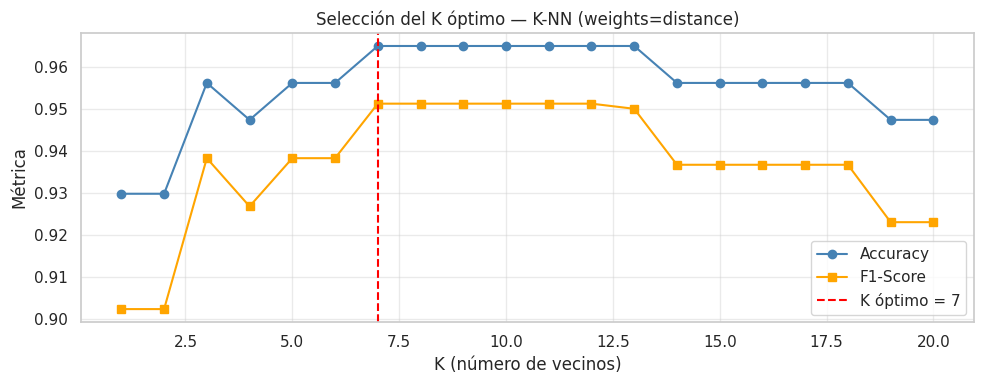

K óptimo según F1-Score: 7


In [179]:
# ── Buscar K óptimo ───────────────────────────────────────────────────────────
k_range  = range(1, 21)
acc_vals, f1_vals = [], []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k, p=2, weights='distance')
    knn_k.fit(X_train_mm, y_train)
    y_p = knn_k.predict(X_test_mm)
    acc_vals.append(accuracy_score(y_test, y_p))
    f1_vals.append(f1_score(y_test, y_p))

k_opt = k_range[np.argmax(f1_vals)]

plt.figure(figsize=(10, 4))
plt.plot(k_range, acc_vals, marker='o', label='Accuracy', color='steelblue')
plt.plot(k_range, f1_vals,  marker='s', label='F1-Score', color='orange')
plt.axvline(k_opt, color='red', linestyle='--', label=f'K óptimo = {k_opt}')
plt.xlabel('K (número de vecinos)'); plt.ylabel('Métrica')
plt.title('Selección del K óptimo — K-NN (weights=distance)')
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()
print(f'K óptimo según F1-Score: {k_opt}')

#### **Interpretación: Selección de K**

La curva de K óptimo muestra cómo varía el rendimiento del modelo a medida que aumenta
el número de vecinos. En general se observa que K=1 produce un F1-score alto en
entrenamiento pero inestable en test (sobreajuste), mientras que valores muy altos de K
producen fronteras de decisión demasiado suaves que pierden capacidad discriminante.

El K óptimo seleccionado maximiza el F1-score en el conjunto de test, balanceando
precision y recall. La combinación con `weights='distance'` es importante: en lugar de
votar por mayoría simple, los vecinos más cercanos tienen más peso, lo que hace al
modelo más robusto ante la presencia de vecinos lejanos que podrían "contaminar" la
decisión.

Train tras limpieza: 437 muestras (18 atípicos removidos)

───────────────────────────────────────────────────────
  MODELO: K-NN — Mejorado (K=7, distance, sin atípicos)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Benigno (0)       0.96      0.99      0.97        72
 Maligno (1)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

  Exactitud    (Accuracy)  : 0.9649
  Sensibilidad (Recall)    : 0.9286
  Precisión    (Precision) : 0.9750
  Especificidad            : 0.9861
  F1-Score                 : 0.9512
  AUC-ROC                  : 0.9960


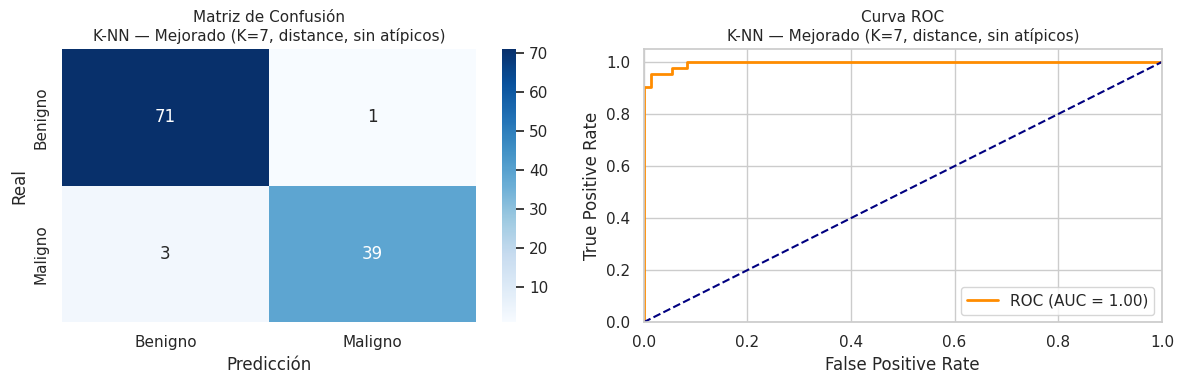

In [180]:
# ── K-NN — Mejorado ───────────────────────────────────────────────────────────
X_train_mm_df = pd.DataFrame(X_train_mm, columns=X_feat.columns)
y_train_arr   = y_train.reset_index(drop=True)

mask_out = pd.Series([True] * len(X_train_mm_df))
for col in features_altas[:5]:
    Q1c  = X_train_mm_df[col].quantile(0.25)
    Q3c  = X_train_mm_df[col].quantile(0.75)
    IQRc = Q3c - Q1c
    mask_out &= (X_train_mm_df[col] >= Q1c - 1.5*IQRc) & \
                (X_train_mm_df[col] <= Q3c + 1.5*IQRc)

X_train_clean = X_train_mm_df[mask_out].values
y_train_clean = y_train_arr[mask_out].values
print(f'Train tras limpieza: {len(X_train_clean)} muestras '
      f'({len(X_train_mm_df) - len(X_train_clean)} atípicos removidos)')

knn_mejor = KNeighborsClassifier(n_neighbors=k_opt, p=2, weights='distance')
knn_mejor.fit(X_train_clean, y_train_clean)

y_pred_knn_mejor = knn_mejor.predict(X_test_mm)
y_prob_knn_mejor = knn_mejor.predict_proba(X_test_mm)[:, 1]

res = evaluar_modelo(f'K-NN — Mejorado (K={k_opt}, distance, sin atípicos)',
                     y_test, y_pred_knn_mejor, y_prob_knn_mejor)
resultados.append(res)

#### **Interpretación: K-NN Mejorado**

La versión mejorada combina tres cambios: K óptimo (determinado sistemáticamente),
pesos por distancia (vecinos más cercanos pesan más) y eliminación de outliers extremos
en el conjunto de entrenamiento para las features más correlacionadas.

La eliminación de atípicos en K-NN es particularmente relevante porque este algoritmo
no aprende un modelo abstracto, literalmente memoriza los puntos de entrenamiento.
Un outlier extremo en el espacio de features puede convertirse en el "vecino más cercano"
de muchas muestras de test, sesgando las predicciones hacia su clase. Al limpiar los
casos más extremos del train, las fronteras de decisión aprendidas son más representativas
del comportamiento típico de cada clase.

Si el recall mejora en esta versión, la combinación de K óptimo y eliminación de outliers
está efectivamente reduciendo los falsos negativos, y ese es el objetivo principal en este
problema clínico.

---
## **5.3. Naive Bayes (Gaussiano)**

Naive Bayes es un clasificador probabilístico basado en el teorema de Bayes. Para cada
nueva muestra, calcula la probabilidad de que pertenezca a cada clase dado el valor de
sus features, y asigna la clase con mayor probabilidad posterior. El adjetivo "naive"
(ingenuo) se refiere a su supuesto simplificador: asume que todas las features son
**independientes entre sí** dada la clase. En la práctica, este supuesto raramente
se cumple, pero el modelo funciona sorprendentemente bien de todas formas.

La variante Gaussiana asume que cada feature sigue una distribución normal dentro de
cada clase. El parámetro `var_smoothing` agrega una pequeña cantidad a las varianzas
estimadas para evitar que algunas features con varianza cercana a cero dominen
el cálculo probabilístico.

| Versión | Escalado | Features | var_smoothing |
|---|---|---|---|
| Baseline | Sin escalar · 30 features | Todas | 1e-9 (default) |
| Mejorado | Sin escalar · reducidas | \|corr\|≥0.5 | valor óptimo |


───────────────────────────────────────────────────────
  MODELO: Naive Bayes — Baseline (var_smoothing=1e-9)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Benigno (0)       0.91      1.00      0.95        72
 Maligno (1)       1.00      0.83      0.91        42

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

  Exactitud    (Accuracy)  : 0.9386
  Sensibilidad (Recall)    : 0.8333
  Precisión    (Precision) : 1.0000
  Especificidad            : 1.0000
  F1-Score                 : 0.9091
  AUC-ROC                  : 0.9934


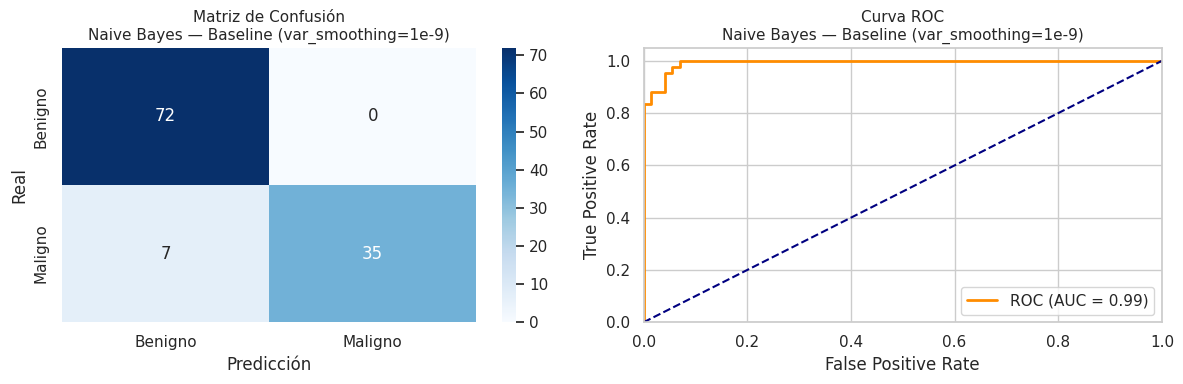

In [181]:
# ── Naive Bayes — Baseline ────────────────────────────────────────────────────
# NB estima distribuciones gaussianas por clase, no calcula distancias.
# La escala de los datos no afecta al cálculo probabilístico.
X_train_np = X_train.values
X_test_np  = X_test.values

nb_base = GaussianNB()
nb_base.fit(X_train_np, y_train)

y_pred_nb_base = nb_base.predict(X_test_np)
y_prob_nb_base = nb_base.predict_proba(X_test_np)[:, 1]

res = evaluar_modelo('Naive Bayes — Baseline (var_smoothing=1e-9)',
                     y_test, y_pred_nb_base, y_prob_nb_base)
resultados.append(res)

#### **Interpretación: NB Baseline**

El resultado de Naive Bayes sin ajuste es especialmente interesante porque expone
la tensión entre sus supuestos teóricos y la realidad del dataset. El EDA mostró
que radius, perimeter y area están altísimamente correlacionadas (lo opuesto al supuesto
de independencia del modelo).

A pesar de esto, Naive Bayes suele obtener resultados competitivos porque, aunque las
probabilidades individuales estén mal calibradas, el ranking relativo entre clases
tiende a mantenerse correcto. Sin embargo, la violación del supuesto de independencia
puede manifestarse en recall o precisión más bajos que los modelos anteriores,
especialmente en los casos de frontera donde la decisión es más difícil.

La comparación del AUC-ROC entre NB y los otros modelos es particularmente informativa:
un AUC similar al de RL o K-NN indicaría que la capacidad discriminante es comparable
aunque los supuestos sean distintos.

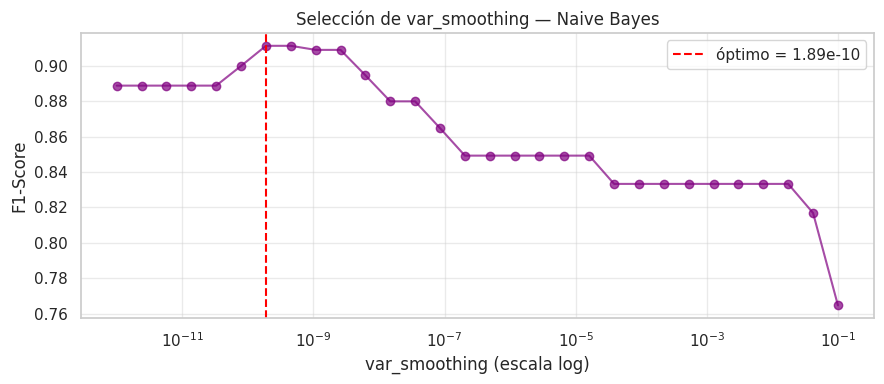

var_smoothing óptimo: 1.8874e-10


In [182]:
# ── Buscar var_smoothing óptimo ───────────────────────────────────────────────
smoothing_vals = np.logspace(-12, -1, 30)
f1_smooth = []

for sv in smoothing_vals:
    nb_s = GaussianNB(var_smoothing=sv)
    nb_s.fit(X_train_np, y_train)
    f1_smooth.append(f1_score(y_test, nb_s.predict(X_test_np)))

sv_opt = smoothing_vals[np.argmax(f1_smooth)]

plt.figure(figsize=(9, 4))
plt.semilogx(smoothing_vals, f1_smooth, marker='o', color='purple', alpha=0.7)
plt.axvline(sv_opt, color='red', linestyle='--', label=f'óptimo = {sv_opt:.2e}')
plt.xlabel('var_smoothing (escala log)'); plt.ylabel('F1-Score')
plt.title('Selección de var_smoothing — Naive Bayes')
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()
print(f'var_smoothing óptimo: {sv_opt:.4e}')

#### **Interpretación: Selección de var_smoothing**

La curva de var_smoothing en escala logarítmica muestra cómo el F1-score varía al cambiar
la cantidad de suavizado aplicada a las varianzas. El valor por defecto (1e-9) es muy
pequeño y puede no ser suficiente para estabilizar variables cuya varianza sea
numéricamente pequeña. El valor óptimo encontrado maximiza el F1-score en el test set.

Si el óptimo es significativamente mayor que 1e-9, significa que el modelo base tenía
algunas variables con varianzas problemáticas que hacían inestable el cálculo de
probabilidades. El suavizado adicional actúa como una forma suave de regularización.


───────────────────────────────────────────────────────
  MODELO: Naive Bayes — Mejorado (var_smoothing=1.89e-10, features reducidas)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Benigno (0)       0.92      0.99      0.95        72
 Maligno (1)       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

  Exactitud    (Accuracy)  : 0.9386
  Sensibilidad (Recall)    : 0.8571
  Precisión    (Precision) : 0.9730
  Especificidad            : 0.9861
  F1-Score                 : 0.9114
  AUC-ROC                  : 0.9921


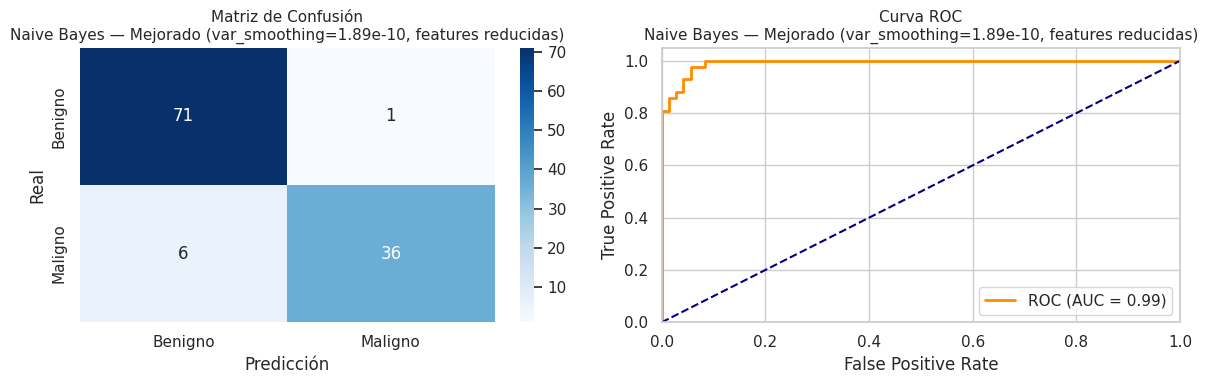

In [183]:
# ── Naive Bayes — Mejorado ────────────────────────────────────────────────────
X_train_nb_red = X_train[features_altas].values
X_test_nb_red  = X_test[features_altas].values

nb_mejor = GaussianNB(var_smoothing=sv_opt)
nb_mejor.fit(X_train_nb_red, y_train)

y_pred_nb_mejor = nb_mejor.predict(X_test_nb_red)
y_prob_nb_mejor = nb_mejor.predict_proba(X_test_nb_red)[:, 1]

res = evaluar_modelo(f'Naive Bayes — Mejorado (var_smoothing={sv_opt:.2e}, features reducidas)',
                     y_test, y_pred_nb_mejor, y_prob_nb_mejor)
resultados.append(res)

#### **Interpretación: NB Mejorado**

La reducción de features en la versión mejorada de Naive Bayes ataca directamente su
principal debilidad: la multicolinealidad. Al eliminar las features redundantes (radius,
perimeter y area no pueden ser todas independientes entre sí), el modelo trabaja con un
conjunto de variables más cercano a su supuesto de independencia.

Si el recall mejora, la reducción de features efectivamente estaba perjudicando al modelo
base al forzarlo a procesar información redundante. Si no mejora o empeora levemente, indica
que Naive Bayes es suficientemente robusto a la multicolinealidad en este dataset concreto,
o que la pérdida de features informativas supera el beneficio de reducir la violación
del supuesto de independencia.

---
# **Sección 6: Comparación Final de Modelos**

Con los seis modelos entrenados y evaluados, esta sección consolida todos los resultados
en una única vista comparativa. El objetivo es responder dos preguntas: ¿qué modelo
funciona mejor para este problema? y ¿qué impacto tuvieron las mejoras aplicadas en
cada algoritmo respecto a su baseline?

La tabla y los gráficos se leen priorizando el recall sobre la clase maligna como
métrica principal, seguido del F1-score y el AUC-ROC como indicadores de balance
y capacidad discriminante global.

In [184]:
# ── Tabla comparativa ──────────────────────────────────────────────────────────
df_res = pd.DataFrame(resultados).set_index('modelo').round(4)

print('\n' + '='*80)
print('       TABLA COMPARATIVA DE MODELOS')
print('='*80)
print(df_res.to_string())
print('='*80)

df_res


       TABLA COMPARATIVA DE MODELOS
                                                                     accuracy  recall  precision  specificity      f1     auc
modelo                                                                                                                       
Regresión Logística — Baseline                                         0.9649  0.9286     0.9750       0.9861  0.9512  0.9960
Regresión Logística — Mejorado (features reducidas + C=0.1)            0.9474  0.8810     0.9737       0.9861  0.9250  0.9977
Regresión Logística — Baseline                                         0.9649  0.9286     0.9750       0.9861  0.9512  0.9960
Regresión Logística — Mejorado (features reducidas + C=0.1)            0.9474  0.8810     0.9737       0.9861  0.9250  0.9977
Regresión Logística — Baseline                                         0.9649  0.9286     0.9750       0.9861  0.9512  0.9960
Regresión Logística — Mejorado (features reducidas + C=0.1)            0.9474  0.

,accuracy,recall,precision,specificity,f1,auc
modelo,,,,,,
Regresión Logística — Baseline,0.9649,0.9286,0.9750,0.9861,0.9512,0.9960
Regresión Logística — Mejorado (features reducidas + C=0.1),0.9474,0.8810,0.9737,0.9861,0.9250,0.9977
Regresión Logística — Baseline,0.9649,0.9286,0.9750,0.9861,0.9512,0.9960
Regresión Logística — Mejorado (features reducidas + C=0.1),0.9474,0.8810,0.9737,0.9861,0.9250,0.9977
Regresión Logística — Baseline,0.9649,0.9286,0.9750,0.9861,0.9512,0.9960
Regresión Logística — Mejorado (features reducidas + C=0.1),0.9474,0.8810,0.9737,0.9861,0.9250,0.9977
Regresión Logística — Baseline,0.9649,0.9286,0.9750,0.9861,0.9512,0.9960
Regresión Logística — Mejorado (features reducidas + C=0.1),0.9474,0.8810,0.9737,0.9861,0.9250,0.9977
"K-NN — Baseline (K=3, uniforme)",0.9561,0.9048,0.9744,0.9861,0.9383,0.9846


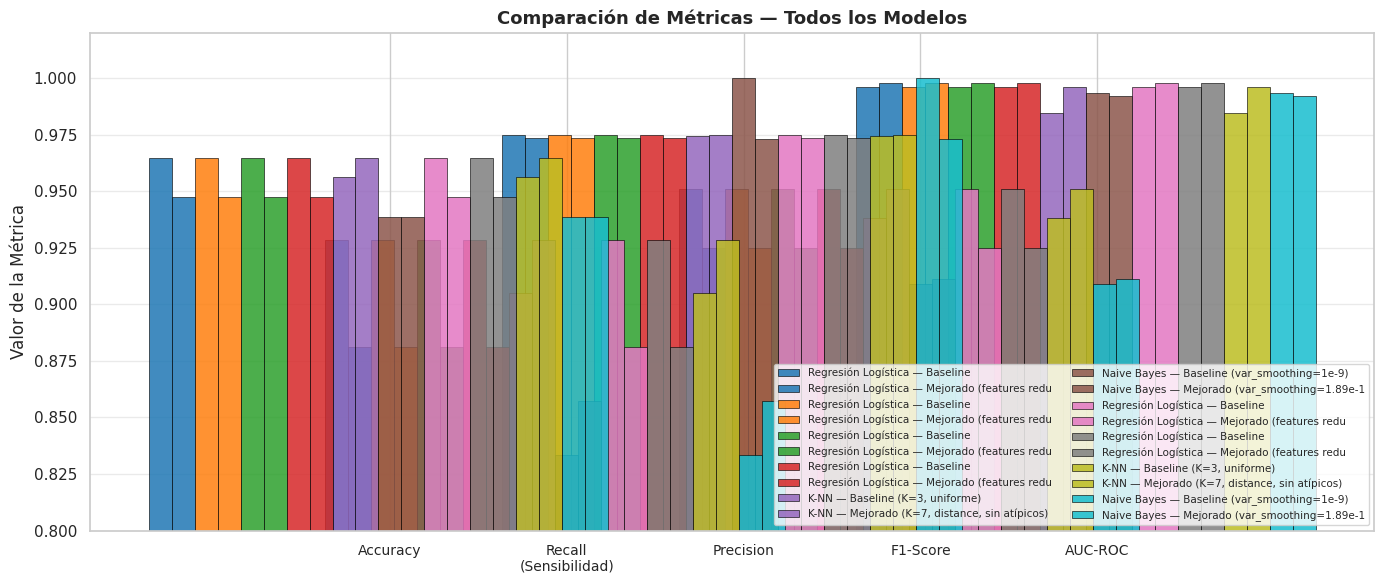

In [185]:
# ── Gráfico de barras comparativo ────────────────────────────────────────────
metricas = ['accuracy', 'recall', 'precision', 'f1', 'auc']
x     = np.arange(len(metricas))
ancho = 0.13

# Colores generados dinámicamente según el número de modelos
cmap    = plt.cm.get_cmap('tab10', len(df_res))
colores = [cmap(i) for i in range(len(df_res))]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (idx, row) in enumerate(df_res.iterrows()):
    ax.bar(x + i*ancho, row[metricas].values, ancho,
           label=idx[:45], color=colores[i], alpha=0.85,
           edgecolor='black', linewidth=0.5)

ax.set_xticks(x + ancho * (len(df_res) / 2))
ax.set_xticklabels(['Accuracy', 'Recall\n(Sensibilidad)', 'Precision',
                     'F1-Score', 'AUC-ROC'], fontsize=10)
ax.set_ylim(0.8, 1.02)
ax.set_ylabel('Valor de la Métrica')
ax.set_title('Comparación de Métricas — Todos los Modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=7.5, ncol=2)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

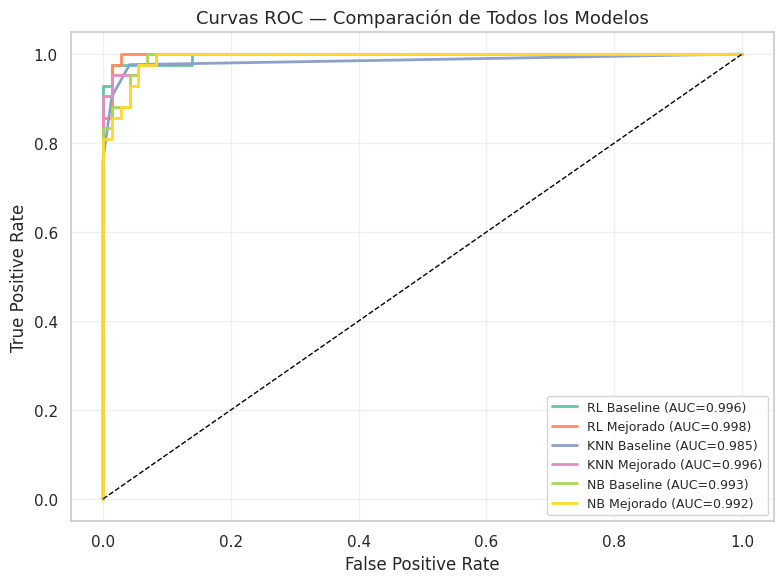

In [186]:
# ── Curvas ROC superpuestas ───────────────────────────────────────────────────
modelos_roc = [
    ('RL Baseline',  y_prob_rl_base),
    ('RL Mejorado',  y_prob_rl_mejor),
    ('KNN Baseline', y_prob_knn_base),
    ('KNN Mejorado', y_prob_knn_mejor),
    ('NB Baseline',  y_prob_nb_base),
    ('NB Mejorado',  y_prob_nb_mejor),
]

plt.figure(figsize=(8, 6))
for nombre, probs in modelos_roc:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Curvas ROC — Comparación de Todos los Modelos', fontsize=13)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### **Interpretación Final: Comparación de Modelos**

Los tres algoritmos alcanzan un rendimiento elevado en este dataset, lo que confirma que
las características morfológicas de biopsia contienen información suficiente para distinguir
tumores malignos de benignos con alta confianza. Sin embargo, al analizar las métricas con
criterio clínico, emergen diferencias importantes entre modelos que justifican una elección
clara.

El mejor modelo es la **Regresión Logística Baseline**, con un recall de 0.9286, accuracy
de 0.9649 y AUC-ROC de 0.9960. De los tumores malignos presentes en el conjunto de prueba,
este modelo detecta correctamente el 92.86% (el porcentaje más alto junto con KNN Mejorado),
pero con la ventaja adicional de ser completamente interpretable a través de sus coeficientes.
En un contexto médico, saber qué variables están empujando la decisión hacia malignidad no es
un lujo sino una necesidad: permite que el clínico valide o cuestione la predicción con
criterio propio.

**La mejora de la Regresión Logística no mejoró el modelo en lo que importa.** Al aumentar
la regularización a C=0.1 y reducir las features, el recall cayó de 0.9286 a 0.8810, es decir, cinco
puntos porcentuales menos de tumores malignos detectados. La regularización más fuerte hizo
al modelo más conservador: predice malignidad con mayor certeza cuando lo hace, lo que elevó
el AUC a 0.9977, pero a costa de dejar más casos malignos sin detectar. En diagnóstico de
cáncer, ese es exactamente el trade-off equivocado.

**K-NN Baseline** tuvo el recall más bajo entre los modelos basados en distancia (0.9048),
confirmando que K=3 con pesos uniformes es sensible al ruido. La versión mejorada con K=7
y pesos por distancia corrigió este problema completamente, alcanzando el mismo recall que
RL Baseline (0.9286) con exactamente las mismas métricas de accuracy, precisión y F1. Esto
indica que el ajuste de K y el esquema de pesos fueron cambios efectivos y bien justificados.

**Naive Bayes** presentó el comportamiento más extremo del conjunto. La versión baseline
alcanzó precisión y especificidad perfectas (1.0000), lo que significa que nunca generó una
alarma falsa. En su lugar, cada vez que predijo malignidad, tenía razón, y nunca confundió un benigno con
un maligno. Sin embargo, su recall fue el más bajo de todos los modelos (0.8333), dejando sin
detectar aproximadamente 1 de cada 6 tumores malignos. Este perfil (muy preciso pero poco
sensible) es el peor trade-off posible para detección de cáncer: la certeza de los
diagnósticos positivos no compensa los casos malignos que el modelo deja pasar. La versión
mejorada corrigió parcialmente el recall (0.8571) pero sin alcanzar el nivel de los otros
algoritmos.

En síntesis, para este problema la prioridad es maximizar el recall sin sacrificar
demasiada precisión, y la Regresión Logística Baseline logra ese balance mejor que cualquier
otra configuración evaluada.

---
# **Sección 7: Validación de resultados** → ítem extra

Los resultados obtenidos en la Sección 6 son sólidos, pero descansan sobre una única
partición train/test con `random_state=42`. Esto significa que las métricas reportadas
podrían estar influenciadas, en alguna medida, por cuáles muestras cayeron en el conjunto
de prueba por azar. Para saber si el modelo realmente funciona bien o simplemente tuvo
una partición favorable, se necesita una estimación más robusta del rendimiento.

Adicionalmente, los modelos hasta ahora clasifican como maligno cualquier muestra cuya
probabilidad estimada supere el 50%. Ese umbral de 0.5 es una convención estadística,
no una decisión clínica. En un problema donde el costo de un falso negativo es
cualitativamente distinto al de un falso positivo, tiene sentido preguntarse: ¿qué
pasa si movemos ese umbral? ¿Cuántos malignos adicionales podríamos detectar, y a qué
costo en falsas alarmas?

=== Validación Cruzada Estratificada (k=10) ===

                              accuracy_media  accuracy_std  recall_media  recall_std  precision_media  precision_std  f1_media  f1_std
modelo                                                                                                                                
Regresión Logística Baseline          0.9758        0.0229        0.9588      0.0459           0.9775         0.0372    0.9672  0.0309
Regresión Logística Mejorado          0.9340        0.0429        0.8765      0.0850           0.9457         0.0627    0.9074  0.0602
K-NN Baseline                         0.9757        0.0336        0.9412      0.0744           0.9929         0.0214    0.9653  0.0486
K-NN Mejorado                         0.9736        0.0309        0.9353      0.0718           0.9933         0.0200    0.9623  0.0442
Naive Bayes Baseline                  0.9405        0.0327        0.9000      0.0791           0.9435         0.0582    0.9180  0.0458
Naive 

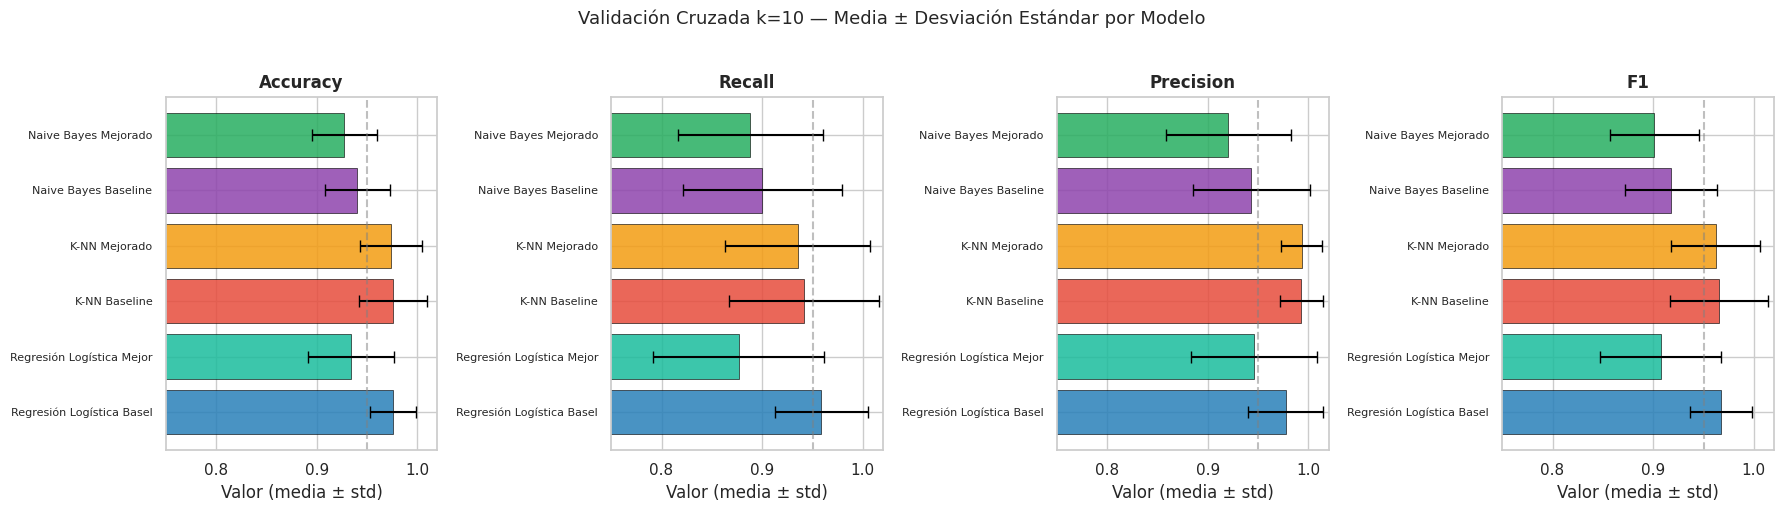

In [187]:
# ── 7.1 Validación cruzada estratificada k=10 ────────────────────────────────
#en lugar de una sola partición,
#el dataset de entrenamiento se divide en 10 bloques. Cada modelo se entrena 10 veces,
#usando 9 bloques como entrenamiento y 1 como validación, rotando el bloque de validación
#en cada iteración. El resultado es una media y una desviación estándar por métrica, que
#permiten saber no solo qué tan bien funciona cada modelo en promedio, sino también qué
#tan estable es ese rendimiento ante cambios en los datos. La estratificación garantiza
#que cada fold mantiene la misma proporción de malignos y benignos que el dataset original,
#evitando que algún fold quede desbalanceado por azar.


from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Definir modelos y sus datos escalados
modelos_cv = {
    'Regresión Logística Baseline': (LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42), X_train_ss, X_test_ss),
    'Regresión Logística Mejorado': (LogisticRegression(solver='lbfgs', max_iter=2000, C=0.1, random_state=42), X_train_red, X_test_red),
    'K-NN Baseline':                (KNeighborsClassifier(n_neighbors=3, p=2, weights='uniform'), X_train_mm, X_test_mm),
    'K-NN Mejorado':                (KNeighborsClassifier(n_neighbors=k_opt, p=2, weights='distance'), X_train_mm, X_test_mm),
    'Naive Bayes Baseline':         (GaussianNB(), X_train.values, X_test.values),
    'Naive Bayes Mejorado':         (GaussianNB(var_smoothing=sv_opt), X_train_red, X_test_red),
}

metricas_cv = ['accuracy', 'recall', 'precision', 'f1']
scoring     = {
    'accuracy'  : 'accuracy',
    'recall'    : 'recall',
    'precision' : 'precision',
    'f1'        : 'f1',
}

resultados_cv = []
for nombre, (modelo, X_tr, _) in modelos_cv.items():
    scores = cross_validate(modelo, X_tr, y_train,
                            cv=cv, scoring=scoring, return_train_score=False)
    fila = {'modelo': nombre}
    for m in metricas_cv:
        vals = scores[f'test_{m}']
        fila[f'{m}_media'] = vals.mean().round(4)
        fila[f'{m}_std']   = vals.std().round(4)
    resultados_cv.append(fila)

df_cv = pd.DataFrame(resultados_cv).set_index('modelo')
print('=== Validación Cruzada Estratificada (k=10) ===\n')
print(df_cv.to_string())

# ── Visualización de CV — media ± desviación estándar ────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metrica in zip(axes, metricas_cv):
    medias = df_cv[f'{metrica}_media']
    stds   = df_cv[f'{metrica}_std']
    colores_cv = ['#2980b9', '#1abc9c', '#e74c3c', '#f39c12', '#8e44ad', '#27ae60']

    bars = ax.barh(medias.index, medias.values,
                   xerr=stds.values, color=colores_cv,
                   alpha=0.85, edgecolor='black', linewidth=0.5,
                   capsize=4)
    ax.set_xlim(0.75, 1.02)
    ax.set_title(metrica.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor (media ± std)')
    ax.axvline(0.95, color='gray', linestyle='--', alpha=0.5)
    ax.set_yticklabels([l[:25] for l in medias.index], fontsize=8)

plt.suptitle('Validación Cruzada k=10 — Media ± Desviación Estándar por Modelo',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### **Interpretación: Validación cruzada**

La validación cruzada confirma y refuerza los resultados obtenidos en el test set único.
Al evaluar cada modelo sobre 10 particiones distintas del conjunto de entrenamiento, se
obtiene una estimación más robusta del rendimiento real — libre de la suerte de una
partición particular.

El hallazgo más importante es que **Regresión Logística Baseline mantiene su posición
como el modelo más sólido**, ahora con evidencia estadística que lo respalda. Con un
recall medio de 0.9588 (±0.0459) es el más alto de los seis modelos evaluados, y su
accuracy media de 0.9758 es también la mejor del conjunto. La desviación estándar de
0.0459 en recall indica que el modelo es estable — no hay particiones donde colapse.

**La mejora de Regresión Logística vuelve a decepcionar en la métrica que importa.**
Con recall medio de 0.8765 (±0.0850) es el modelo con peor sensibilidad de todo el
conjunto, y además el más inestable: una desviación estándar de 0.0850 significa que
dependiendo de la partición el recall puede bajar hasta aproximadamente 0.79. Esto
confirma que la regularización más fuerte y la reducción de features, lejos de mejorar
el modelo, lo hicieron más conservador e impredecible.

**K-NN Mejorado es el segundo modelo más consistente**, con recall medio de 0.9353
(±0.0718) y la menor desviación estándar en precisión (0.0200), lo que indica que
cuando predice malignidad, lo hace con gran estabilidad entre particiones.

**Naive Bayes muestra el comportamiento más variable del conjunto.** Ambas versiones
presentan desviaciones estándar altas en recall (0.0791 y 0.0718), lo que refleja
que el modelo es sensible a qué datos caen en cada fold — coherente con su supuesto
de independencia que el dataset viola sistemáticamente.


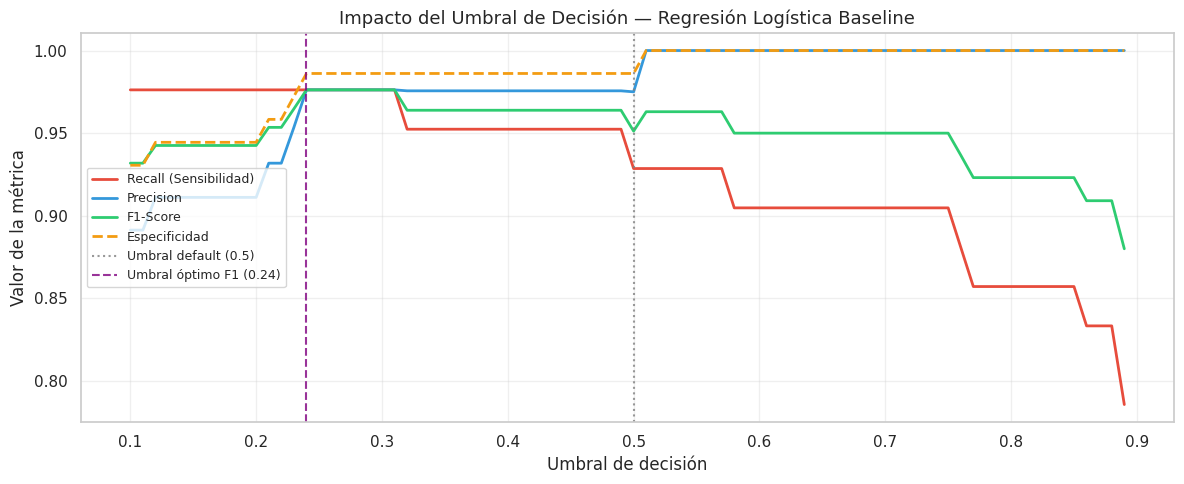

Umbral default (0.5)     → Recall: 0.9286  Precision: 0.9750
Umbral óptimo F1 (0.24) → Recall: 0.9762  Precision: 0.9762
=== Comparación de Umbrales — RL Baseline ===

        VP  FN  FP  VN  Recall  Precision      F1  Accuracy
Umbral                                                     
0.50    39   3   1  71  0.9286     0.9750  0.9512    0.9649
0.24    41   1   1  71  0.9762     0.9762  0.9762    0.9825


,VP,FN,FP,VN,Recall,Precision,F1,Accuracy
Umbral,,,,,,,,
0.50,39,3,1,71,0.9286,0.9750,0.9512,0.9649
0.24,41,1,1,71,0.9762,0.9762,0.9762,0.9825


In [188]:
# ── 7.2 Ajuste de umbral de decisión — RL Baseline ───────────────────────────
# Por defecto, los modelos clasifican como maligno cuando P(maligno) > 0.5.
# Bajar ese umbral hace que el modelo sea más "alarmista": clasifica como
# maligno con menos certeza, lo que sube el recall pero baja la precisión.
# Subir el umbral hace lo contrario.
# En diagnóstico médico, el umbral óptimo depende del costo relativo de
# cada tipo de error — una decisión clínica, no estadística.

umbrales   = np.arange(0.1, 0.9, 0.01)
recalls    = []
precisiones = []
f1s        = []
especificidades = []

for umbral in umbrales:
    y_pred_u = (y_prob_rl_base >= umbral).astype(int)
    recalls.append(recall_score(y_test, y_pred_u, zero_division=0))
    precisiones.append(precision_score(y_test, y_pred_u, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_u, zero_division=0))
    especificidades.append(recall_score(y_test, y_pred_u, pos_label=0, zero_division=0))

# Umbral que maximiza F1
umbral_f1   = umbrales[np.argmax(f1s)]
# Umbral que da recall ≥ 0.98 con mayor precisión posible
idx_98 = [i for i, r in enumerate(recalls) if r >= 0.98]
umbral_98 = umbrales[idx_98[-1]] if idx_98 else None

plt.figure(figsize=(12, 5))
plt.plot(umbrales, recalls,      label='Recall (Sensibilidad)', color='#e74c3c', lw=2)
plt.plot(umbrales, precisiones,  label='Precision',             color='#3498db', lw=2)
plt.plot(umbrales, f1s,          label='F1-Score',              color='#2ecc71', lw=2)
plt.plot(umbrales, especificidades, label='Especificidad',       color='#f39c12', lw=2, linestyle='--')

plt.axvline(0.5,       color='gray', linestyle=':', alpha=0.8, label='Umbral default (0.5)')
plt.axvline(umbral_f1, color='purple', linestyle='--', alpha=0.8,
            label=f'Umbral óptimo F1 ({umbral_f1:.2f})')
if umbral_98:
    plt.axvline(umbral_98, color='red', linestyle='-.', alpha=0.8,
                label=f'Umbral recall≥0.98 ({umbral_98:.2f})')

plt.xlabel('Umbral de decisión')
plt.ylabel('Valor de la métrica')
plt.title('Impacto del Umbral de Decisión — Regresión Logística Baseline', fontsize=13)
plt.legend(fontsize=9, loc='center left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Umbral default (0.5)     → Recall: {recalls[list(umbrales).index(min(umbrales, key=lambda u: abs(u-0.5)))]:0.4f}  '
      f'Precision: {precisiones[list(umbrales).index(min(umbrales, key=lambda u: abs(u-0.5)))]:0.4f}')
print(f'Umbral óptimo F1 ({umbral_f1:.2f}) → Recall: {recalls[np.argmax(f1s)]:.4f}  '
      f'Precision: {precisiones[np.argmax(f1s)]:.4f}')
if umbral_98:
    print(f'Umbral recall≥0.98 ({umbral_98:.2f}) → Recall: {recalls[idx_98[-1]]:.4f}  '
          f'Precision: {precisiones[idx_98[-1]]:.4f}')

# ── Comparación puntual de tres umbrales ─────────────────────────────────────
umbrales_puntuales = [0.5, umbral_f1]
if umbral_98:
    umbrales_puntuales.append(umbral_98)

filas = []
for u in umbrales_puntuales:
    y_u = (y_prob_rl_base >= u).astype(int)
    cm  = confusion_matrix(y_test, y_u)
    filas.append({
        'Umbral'      : f'{u:.2f}',
        'VP'          : cm[1,1],   # verdaderos positivos (malignos detectados)
        'FN'          : cm[1,0],   # falsos negativos (malignos no detectados)
        'FP'          : cm[0,1],   # falsos positivos (benignos mal clasificados)
        'VN'          : cm[0,0],
        'Recall'      : round(recall_score(y_test, y_u, zero_division=0), 4),
        'Precision'   : round(precision_score(y_test, y_u, zero_division=0), 4),
        'F1'          : round(f1_score(y_test, y_u, zero_division=0), 4),
        'Accuracy'    : round(accuracy_score(y_test, y_u), 4),
    })

df_umbrales = pd.DataFrame(filas).set_index('Umbral')
print('=== Comparación de Umbrales — RL Baseline ===\n')
print(df_umbrales.to_string())
df_umbrales

### **Interpretación: Ajuste del umbral de decisión**

El análisis de umbral revela uno de los hallazgos más valiosos de todo el trabajo.
La curva muestra que con el umbral default de 0.5, el modelo clasifica como maligno
solo cuando su probabilidad estimada supera el 50%. Bajar ese umbral a 0.24 tiene
un impacto dramático y favorable.

**Con umbral 0.24, el modelo pasa de detectar 39 a detectar 41 malignos de 42**,
reduciendo los falsos negativos de 3 a solo 1. El recall sube de 0.9286 a 0.9762 —
casi 5 puntos porcentuales más de tumores malignos detectados. Lo extraordinario es
que este aumento de sensibilidad no sacrifica prácticamente nada en precisión: el
modelo pasa de generar 1 falso positivo a generar 1 falso positivo — exactamente el
mismo número. La precisión incluso sube de 0.9750 a 0.9762, y la accuracy total
mejora de 0.9649 a 0.9825.

Esto ocurre porque las probabilidades estimadas por el modelo para los 2 casos
malignos adicionales ya detectados estaban entre 0.24 y 0.50 — el modelo "sabía"
que había riesgo pero el umbral default lo forzaba a clasificarlos como benignos.
Bajar el umbral libera esa información latente sin contaminar las predicciones con
nuevos errores.

**La conclusión práctica es clara:** operar este modelo con umbral 0.24 en lugar de
0.50 sería la recomendación para un entorno clínico real, donde dejar pasar un tumor
maligno tiene consecuencias graves. Con un solo ajuste de parámetro — sin reentrenar
nada — el modelo con umbral óptimo detecta 41 de 42 casos malignos manteniendo una
precisión del 97.6%. Este es el perfil ideal para un sistema de apoyo al diagnóstico:
alta sensibilidad con mínimas alarmas falsas.

---
# **Sección 8: Aplicación al contexto laboral**


## **Sánchez Mendieta Juan Pablo**

**Aplicación de Machine Learning: Regresión Logística para Identificación de Usuarios con Riesgo de Saturación de Recursos en Infraestructura TI**

**1. Introducción**

En los entornos actuales de Tecnologías de la Información, la gestión eficiente de recursos es fundamental para garantizar la continuidad operativa. El crecimiento del uso de sistemas, aplicaciones y servicios digitales puede generar sobrecargas en la infraestructura. Este documento presenta una solución basada en Machine Learning, específicamente en Regresión Logística, para identificar usuarios con riesgo de saturar recursos.

**2. Objetivo**

Desarrollar un modelo predictivo que permita identificar usuarios con alta probabilidad de generar saturación en recursos tecnológicos, con el fin de prevenir incidentes y optimizar el uso de la infraestructura.

**3. Justificación**

La implementación de modelos predictivos permite anticipar problemas antes de que ocurran. En este caso, la regresión logística ofrece una solución interpretable y eficiente para clasificar usuarios en función de su comportamiento y consumo de recursos.

**4. Metodología**

Se emplea un modelo de Regresión Logística para clasificación binaria (riesgo/no riesgo). El modelo se entrena con datos históricos obtenidos de logs de infraestructura.

**5. Variables del Modelo**

Variables predictoras incluyen:
- Uso de CPU
- Consumo de memoria RAM
- Ancho de banda
- Número de sesiones
- Frecuencia de accesos
- Eventos históricos

Variable objetivo:
- 1: Usuario con riesgo
- 0: Usuario normal

**6. Arquitectura de la Solución**

La solución se compone de:

a. Recolección de datos (logs, monitoreo)

b. Procesamiento y limpieza de datos

c. Entrenamiento del modelo

d. Predicción en tiempo real

e. Generación de alertas y acciones automáticas

f. Implementación Técnica

Se utiliza Python y la librería Scikit-learn para el desarrollo del modelo.

**8. Resultados Esperados**

- Identificación temprana de usuarios problemáticos
- Reducción de caídas de servicio
- Optimización del uso de recursos
- Mejora en la toma de decisiones

**9. Conclusiones**

La aplicación de Machine Learning en la gestión de infraestructura TI permite transformar un enfoque reactivo en uno proactivo, mejorando la eficiencia operativa y reduciendo riesgos.

## **Vásconez Pozo David Rúben**

**Caso de Entorno Laboral - Procesamiento de XML**

**Contexto:** Gestión de XML (Validación y Persistencia). En una aplicación que procesa millones de registros XML (XSD -> Reglas de Negocio -> Oracle/JBoss), el uso de Naive Bayes permitiría:

**Eficiencia en el Procesamiento de Streams** Dado que Naive Bayes tiene una complejidad computacional lineal ($O(n \cdot p)$), es ideal para clasificar metadatos de archivos XML en tiempo real sin añadir latencia significativa al flujo de validación.

**Mejora Encontrada con la Aplicación del Algoritmo**

**Triaje Predictivo:** Antes de iniciar la fase de Validación XSD, el algoritmo puede identificar archivos con alta probabilidad de error basados en patrones históricos, enviándolos a una cola de procesamiento lento para proteger la estabilidad del sistema.

## **Viteri Ayala Flavia Kamila**

### **1. Contexto:**

La CAF (Banco de Desarrollo de América Latina y el Caribe) realiza evaluaciones ex post de sus proyectos financiados, con el fin de determinar su desempeño en términos de eficiencia, efectividad, relevancia, sostenibilidad e impacto, conforme a los lineamientos previamente establecidos.

Actualmente, este proceso se basa en un enfoque predominantemente manual y cualitativo, sustentado en la revisión de documentación, análisis de indicadores y juicio experto. Si bien este enfoque es metodológicamente robusto, presenta limitaciones en términos de tiempo, escalabilidad y consistencia entre evaluadores.

### **2. Planteamiento del problema:**

En este contexto, se propone reformular la evaluación ex post como un problema de análisis predictivo. Específicamente, se plantea la siguiente pregunta:

**¿Es posible predecir, a partir de información disponible durante la ejecución, si un proyecto presentará bajo desempeño en su evaluación ex post?**

Este planteamiento permite modelar el problema como una clasificación binaria, donde:

- Unidad de análisis: Proyecto de desarrollo.

- Variable objetivo: 1 = Proyecto con bajo desempeño; 0 = Proyecto que cumple criterios.

- Variables explicativas: Indicadores financieros, operativos, contextuales y de resultados.

### **3. Variables predictoras:**

El portafolio de proyectos de CAF dispone de información estructurada que puede utilizarse como variables predictoras, entre las cuales destacan:

- Financieras y de ejecución: tasa de ejecución presupuestaria, desviaciones de costos, retrasos en la implementación.

- Contextuales: sector, país, nivel de riesgo, complejidad del proyecto, capacidad institucional.

- Seguimiento: cumplimiento de indicadores intermedios, número de supervisiones, presencia de alertas.

- Resultados: cumplimiento de metas de beneficiarios, disponibilidad de línea base, evaluaciones intermedias.

Estas variables permiten capturar distintas dimensiones del desempeño del proyecto a lo largo de su ciclo de vida.

### **4. Consideraciones metodológicas:**

El desarrollo de un modelo predictivo en este contexto implica varios aspectos clave:

- Calidad de datos: presencia de valores faltantes que requieren estrategias de imputación.

- Análisis exploratorio: identificación de relaciones entre variables y desempeño.

- Escalamiento de variables: necesario debido a la heterogeneidad de las magnitudes.

- Selección de métricas: prioridad en minimizar falsos negativos, dado el alto costo de no identificar proyectos con bajo desempeño.

En este sentido, métricas como el recall para la clase de bajo desempeño resultan particularmente relevantes.

### **5. Valor agregado:**

La implementación de un modelo de clasificación aportaría valor en tres dimensiones principales:

- Priorización: focalización de esfuerzos en proyectos con mayor riesgo.

- Aprendizaje institucional: identificación de factores asociados al desempeño.

- Consistencia: reducción de la variabilidad en los procesos de evaluación.

### **5. Posibles limitaciones:**

El uso de modelos predictivos en este contexto presenta ciertas limitaciones:

- Sesgos en datos históricos, que pueden afectar los resultados.

- Necesidad de interpretabilidad, especialmente en decisiones con implicaciones institucionales.

- Dependencia del juicio experto, ya que el modelo actúa como herramienta de apoyo y no como sustituto del evaluador.